In [ ]:
# import necessary libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import matthews_corrcoef
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
import shap
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import  StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, StratifiedKFold
from xgboost import XGBClassifier
from statsmodels.stats.contingency_tables import mcnemar
from itertools import combinations
from sklearn.metrics import precision_recall_curve, average_precision_score
from scipy.stats import norm


In [ ]:
from google.colab import files
file = files.upload()

Saving equipment_anomaly_data.csv to equipment_anomaly_data (1).csv


In [ ]:
data = pd.read_csv("equipment_anomaly_data.csv")

/tmp/ipykernel_3587/389068941.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("equipment_anomaly_data.csv")


**DATA PREPERATION**

In [ ]:
data.head()

,temperature,pressure,vibration,humidity,equipment,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   faulty       7672 non-null   float64
dtypes: float64(5), object(1)
memory usage: 48.0+ MB


In [ ]:
# Removing rows where cells have NAN values
data_clean = data.dropna(how='all')

print(data_clean.shape)
print(data_clean.isnull().sum())
data = data_clean

(7672, 6)
temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
faulty         0
dtype: int64


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7672 entries, 0 to 7671
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   faulty       7672 non-null   float64
dtypes: float64(5), object(1)
memory usage: 419.6+ KB


In [ ]:
data.describe()

,temperature,pressure,vibration,humidity,faulty
count,7672.000000,7672.000000,7672.000000,7672.000000,7672.000000
mean,70.922478,35.738048,1.611809,50.016574,0.099974
std,16.200059,10.381593,0.728560,11.841479,0.299985
min,10.269385,3.620798,-0.428188,10.215077,0.000000
25%,62.777057,29.485682,1.170906,42.612817,0.000000
50%,70.156900,35.227544,1.533113,50.024744,0.000000
75%,77.568387,41.159913,1.924700,57.340513,0.000000
max,149.690420,79.887734,4.990537,89.984718,1.000000


In [ ]:
data.columns

Index(['temperature', 'pressure', 'vibration', 'humidity', 'equipment',
       'faulty'],
      dtype='object')

In [ ]:
data["equipment"].value_counts()

,count
equipment,
Compressor,2573
Turbine,2565
Pump,2534


In [ ]:
print(data.isnull().sum())

temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
faulty         0
dtype: int64


In [ ]:
print(data.duplicated().sum())

0


In [ ]:
data = data.drop("equipment", axis=1)


**EXPLORATORY DATA ANAYSIS**

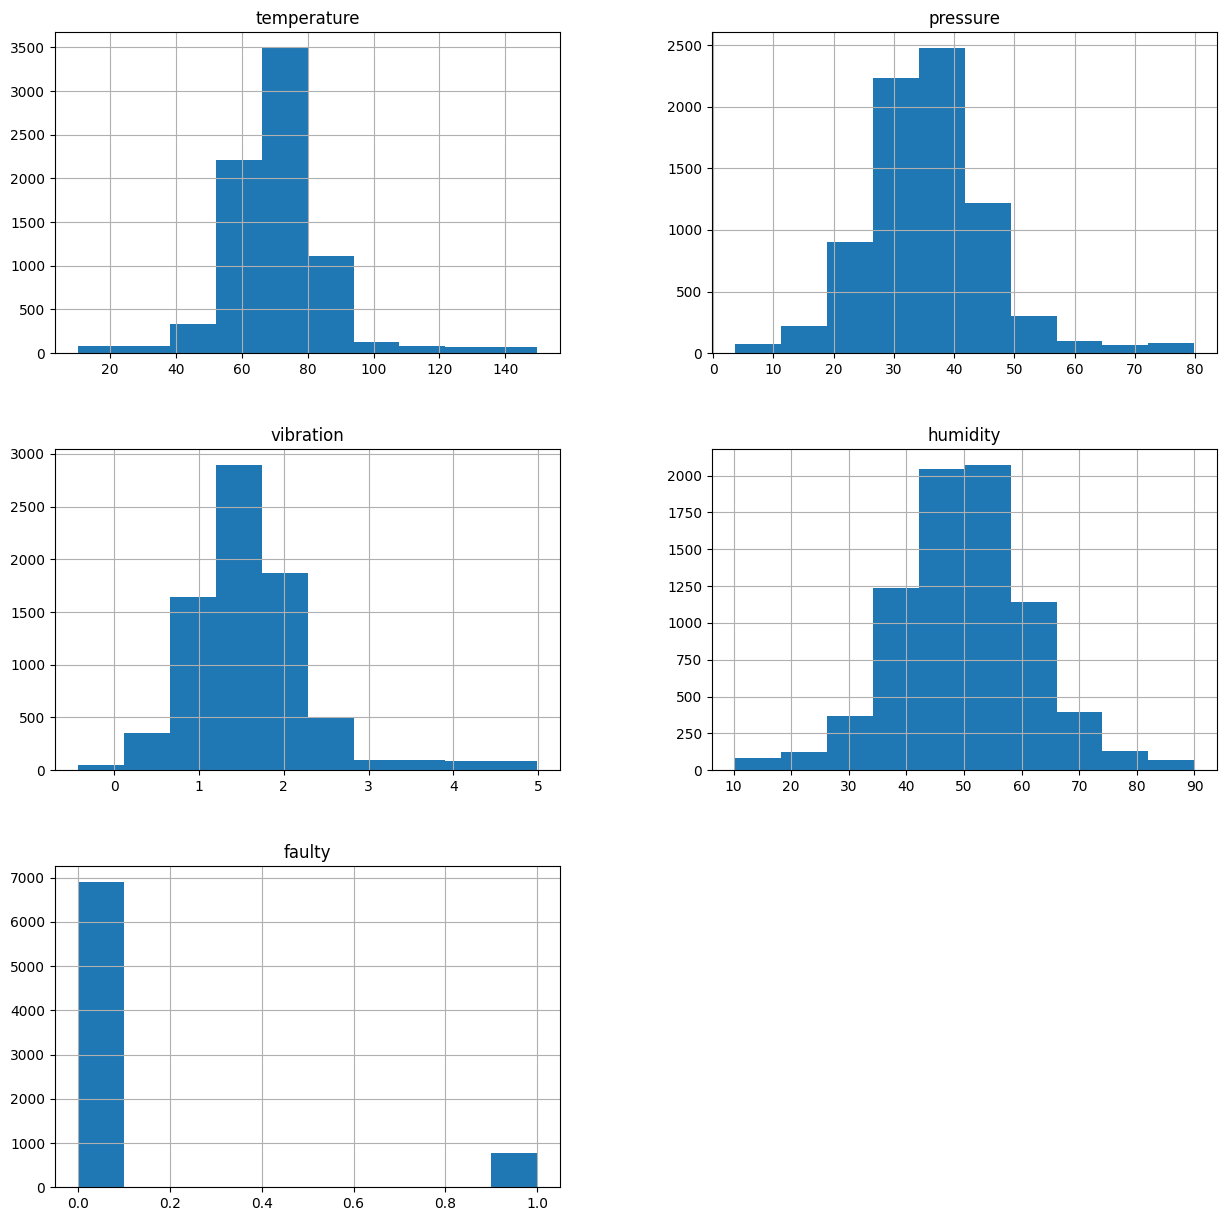

In [ ]:
data.hist(figsize=(15,15))
plt.show()

<Axes: xlabel='faulty', ylabel='temperature'>

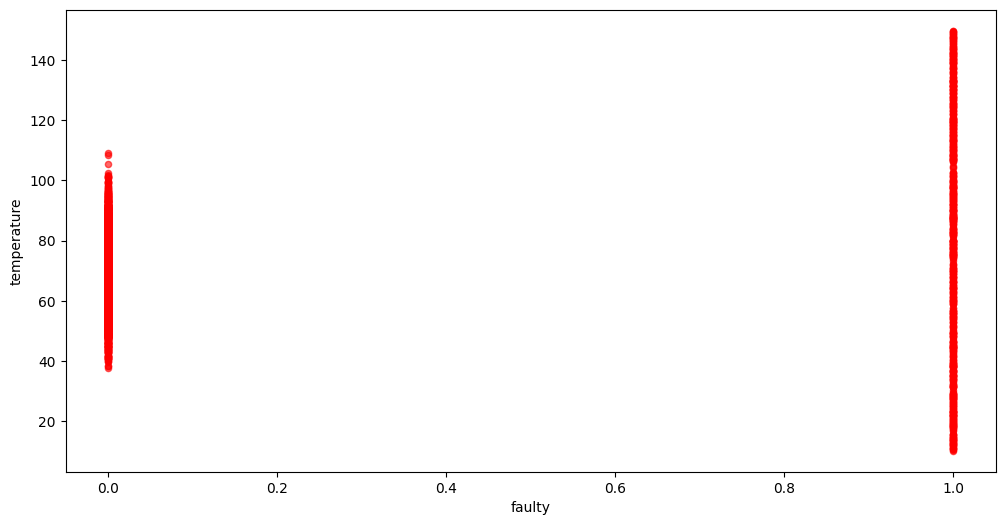

In [ ]:
data.plot(kind = "scatter", figsize = (12,6), color = "red", alpha = 0.6, x = "faulty", y = "temperature")

<Axes: xlabel='faulty', ylabel='pressure'>

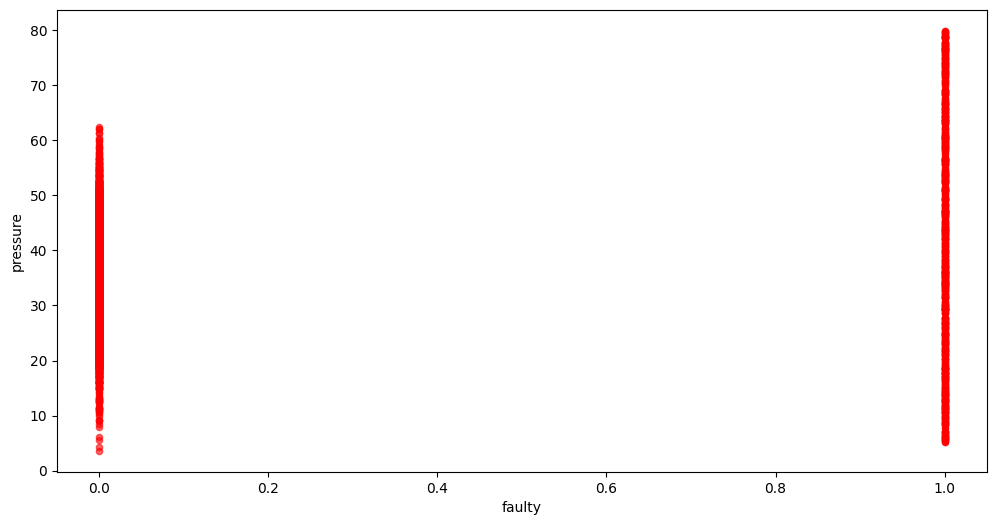

In [ ]:
data.plot(kind = "scatter", figsize = (12,6), color = "red", alpha = 0.6, x = "faulty", y = "pressure")

<Axes: xlabel='faulty', ylabel='humidity'>

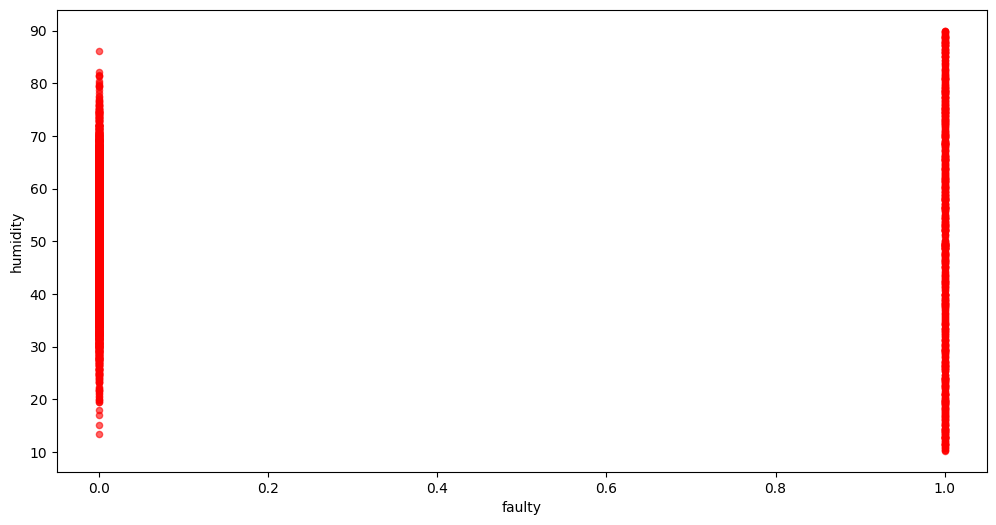

In [ ]:
data.plot(kind = "scatter", figsize = (12,6), color = "red", alpha = 0.6, x = "faulty", y = "humidity")

<Axes: xlabel='faulty', ylabel='vibration'>

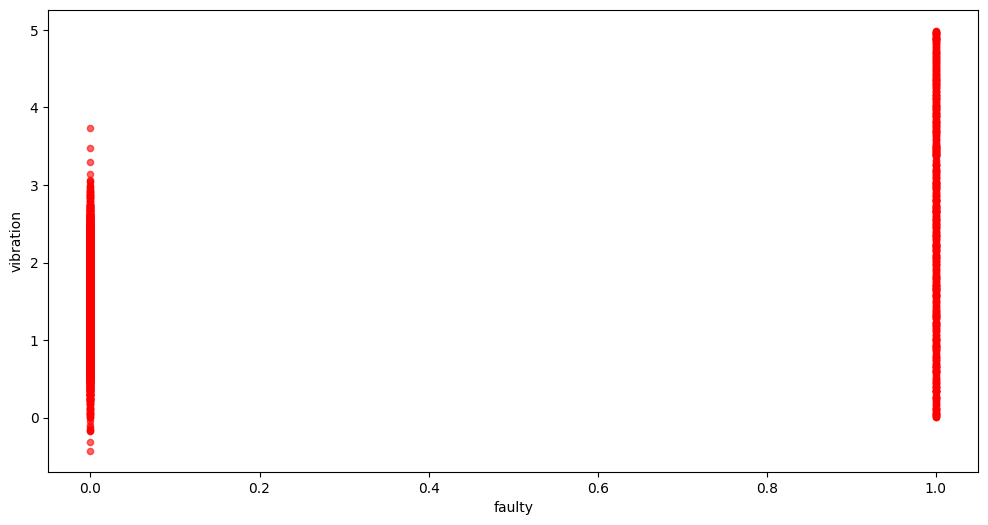

In [ ]:
data.plot(kind = "scatter", figsize = (12,6), color = "red", alpha = 0.6, x = "faulty", y ="vibration")

<Axes: xlabel='vibration', ylabel='temperature'>

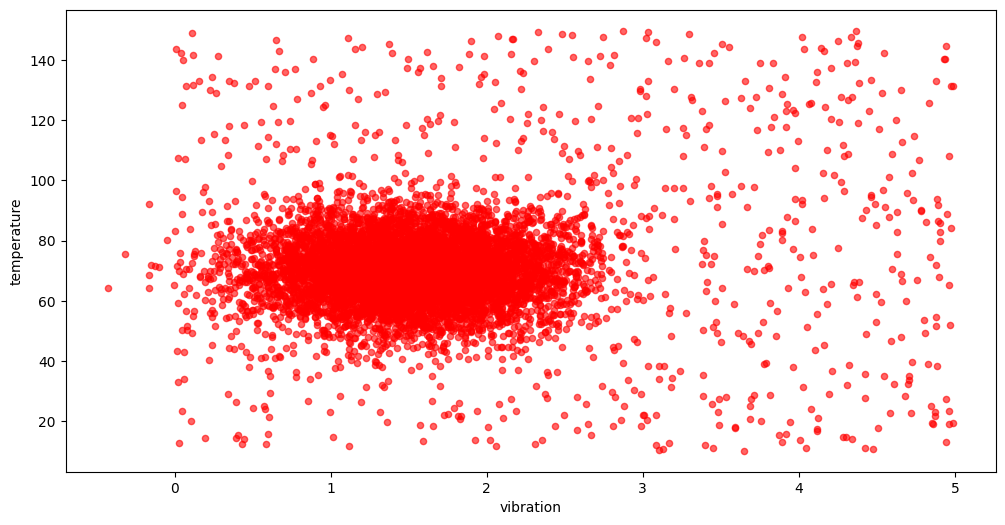

In [ ]:
data.plot(kind = "scatter", figsize = (12,6), color = "red", alpha = 0.6, x = "vibration", y = "temperature")

<Axes: xlabel='pressure', ylabel='temperature'>

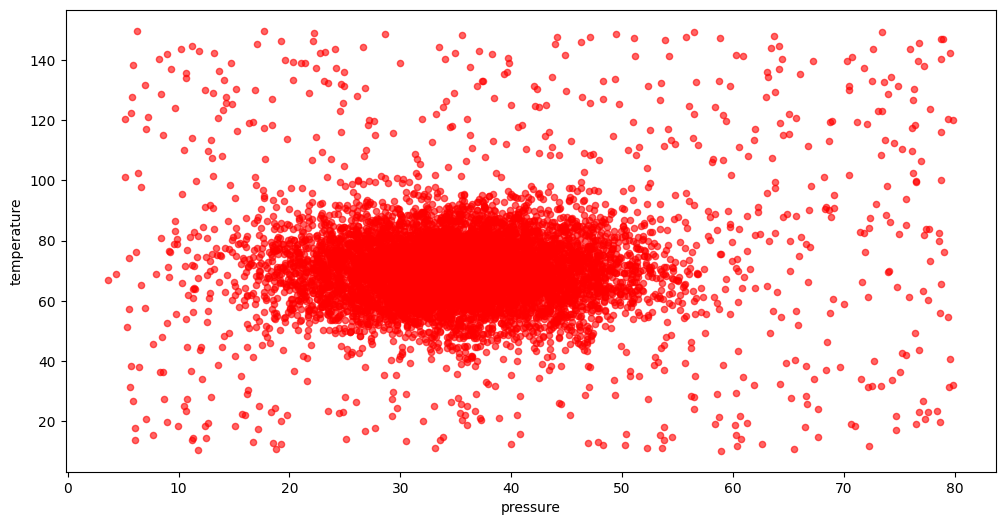

In [ ]:
data.plot(kind = "scatter", figsize = (12,6), color = "red", alpha = 0.6, x = "pressure", y = "temperature")

<Axes: xlabel='humidity', ylabel='temperature'>

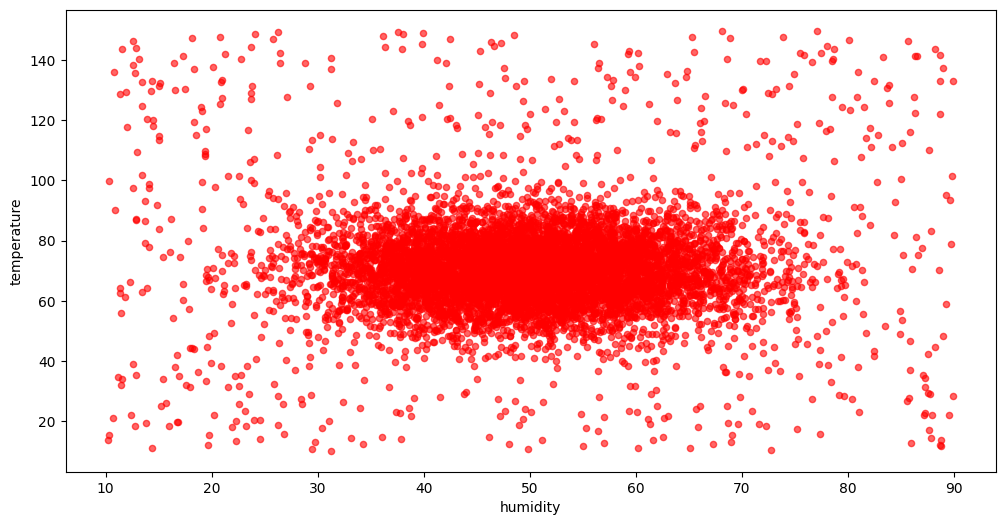

In [ ]:
data.plot(kind = "scatter", figsize = (12,6), color = "red", alpha = 0.6, x = "humidity", y = "temperature")

In [ ]:
# to find the correlating value between metrics

corr_matrix = data.corr(numeric_only = True)
corr_matrix["faulty"].sort_values(ascending=False)

,faulty
faulty,1.000000
vibration,0.431409
pressure,0.202285
temperature,0.184296
humidity,0.012652


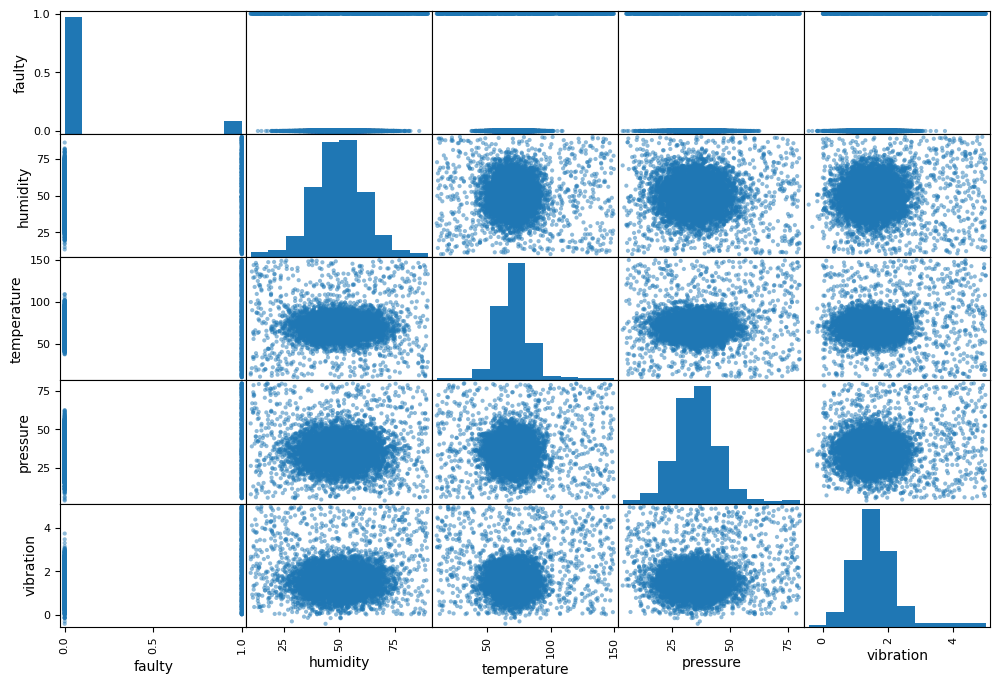

In [ ]:
import pandas as pd
from pandas.plotting import scatter_matrix

features = ['faulty', 'humidity', 'temperature', 'pressure', 'vibration']
scatter_matrix(data[features], figsize=(12, 8), grid = True)
plt.show()

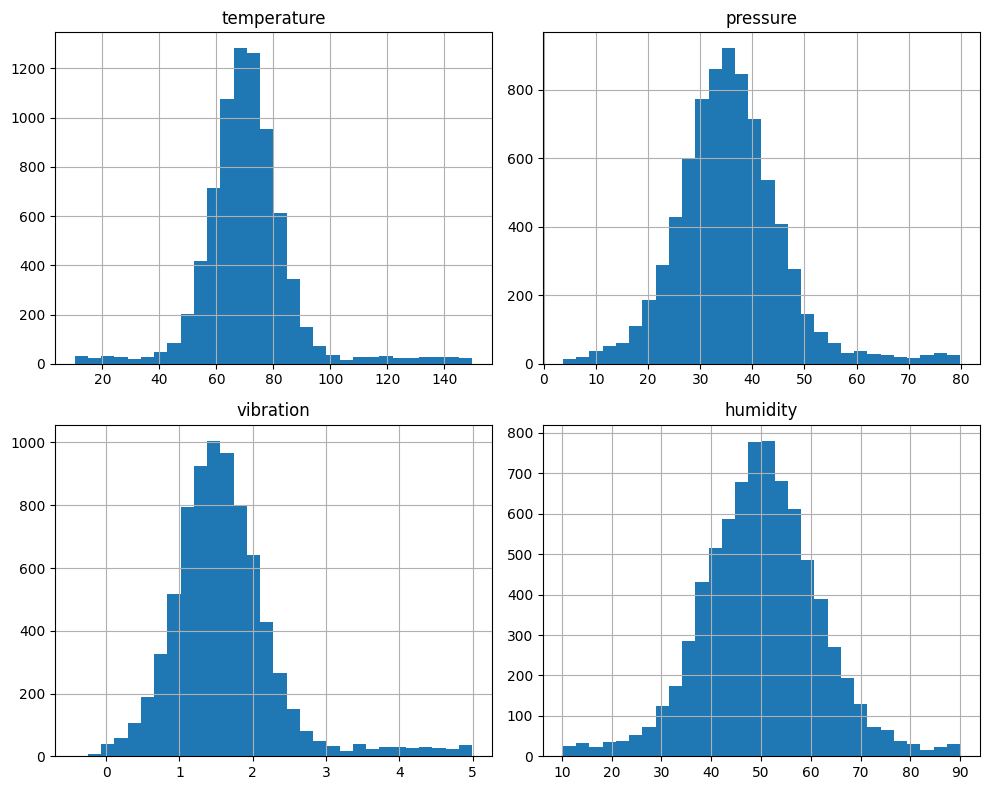

In [ ]:
num_cols = ["temperature", "pressure", "vibration", "humidity"]

# Histogram
data[num_cols].hist(bins=30, figsize=(10, 8))
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

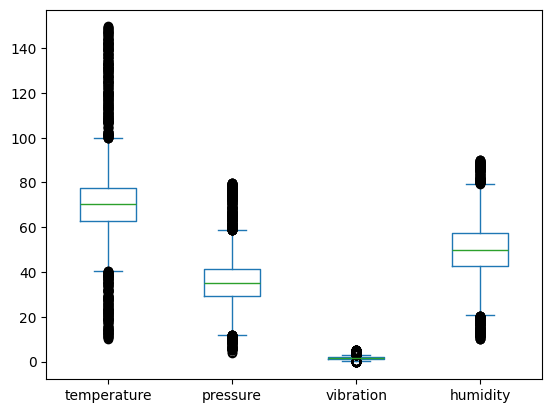

In [ ]:
num_cols = ["temperature", "pressure", "vibration", "humidity"]

# Boxplots for outliers
plt.figure(figsize=(10, 6))
data[num_cols].plot(kind="box")
plt.show()

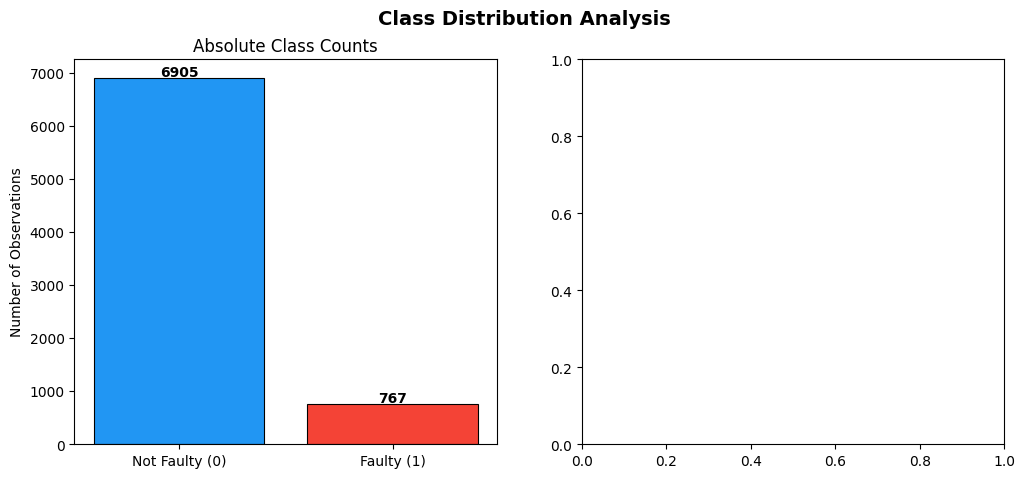

In [ ]:
feature_cols = ['temperature', 'humidity', 'pressure', 'vibration']
target_col   = 'faulty'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution Analysis', fontsize=14, fontweight='bold')

# Count plot
class_counts = data[target_col].value_counts()
colors = ['#2196F3', '#F44336']
axes[0].bar(['Not Faulty (0)', 'Faulty (1)'],
            class_counts.values,
            color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Absolute Class Counts')
axes[0].set_ylabel('Number of Observations')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')


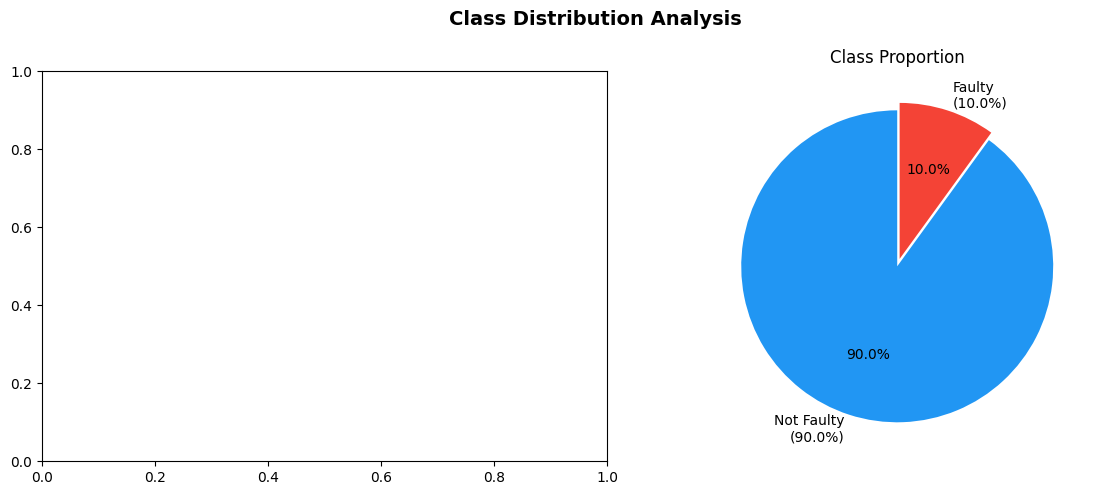


Class Distribution:
  Not Faulty : 6905 (90.00%)
  Faulty     : 767 (10.00%)
  Imbalance ratio (neg:pos) : 9.00:1


In [ ]:
feature_cols = ['temperature', 'humidity', 'pressure', 'vibration']
target_col   = 'faulty'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution Analysis', fontsize=14, fontweight='bold')

# Percentage pie chart
axes[1].pie(class_counts.values,
            labels=[f'Not Faulty\n({class_counts.values[0]/len(data)*100:.1f}%)',
                    f'Faulty\n({class_counts.values[1]/len(data)*100:.1f}%)'],
            colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('eda_class_imbalance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nClass Distribution:")
print(f"  Not Faulty : {class_counts[0]} ({class_counts[0]/len(data)*100:.2f}%)")
print(f"  Faulty     : {class_counts[1]} ({class_counts[1]/len(data)*100:.2f}%)")
print(f"  Imbalance ratio (neg:pos) : {class_counts[0]/class_counts[1]:.2f}:1")

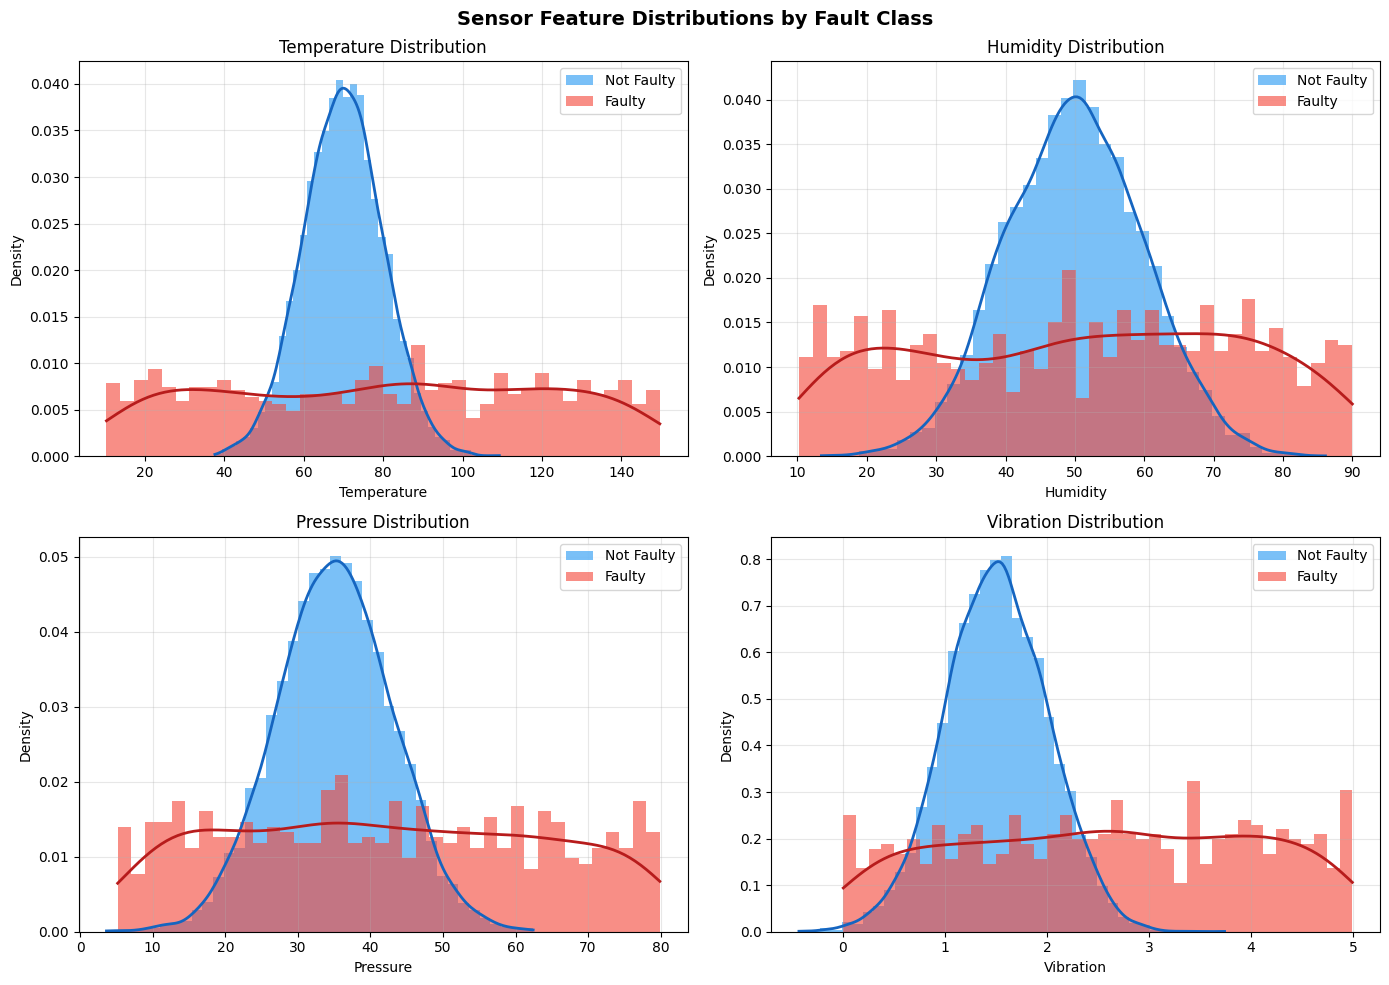

In [ ]:
feature_cols = ['temperature', 'humidity', 'pressure', 'vibration']
target_col   = 'faulty'


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sensor Feature Distributions by Fault Class',
             fontsize=14, fontweight='bold')

faulty     = data[data[target_col] == 1]
not_faulty = data[data[target_col] == 0]

for ax, feature in zip(axes.flatten(), feature_cols):
    ax.hist(not_faulty[feature], bins=40, alpha=0.6,
            color='#2196F3', label='Not Faulty', density=True)
    ax.hist(faulty[feature], bins=40, alpha=0.6,
            color='#F44336', label='Faulty', density=True)

    # Add KDE curves
    for subset, color in [(not_faulty, '#1565C0'), (faulty, '#B71C1C')]:
        kde_x = np.linspace(subset[feature].min(), subset[feature].max(), 200)
        kde   = stats.gaussian_kde(subset[feature].dropna())
        ax.plot(kde_x, kde(kde_x), color=color, linewidth=2)

    ax.set_title(f'{feature.capitalize()} Distribution')
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_distributions_by_class.png', dpi=300, bbox_inches='tight')
plt.show()


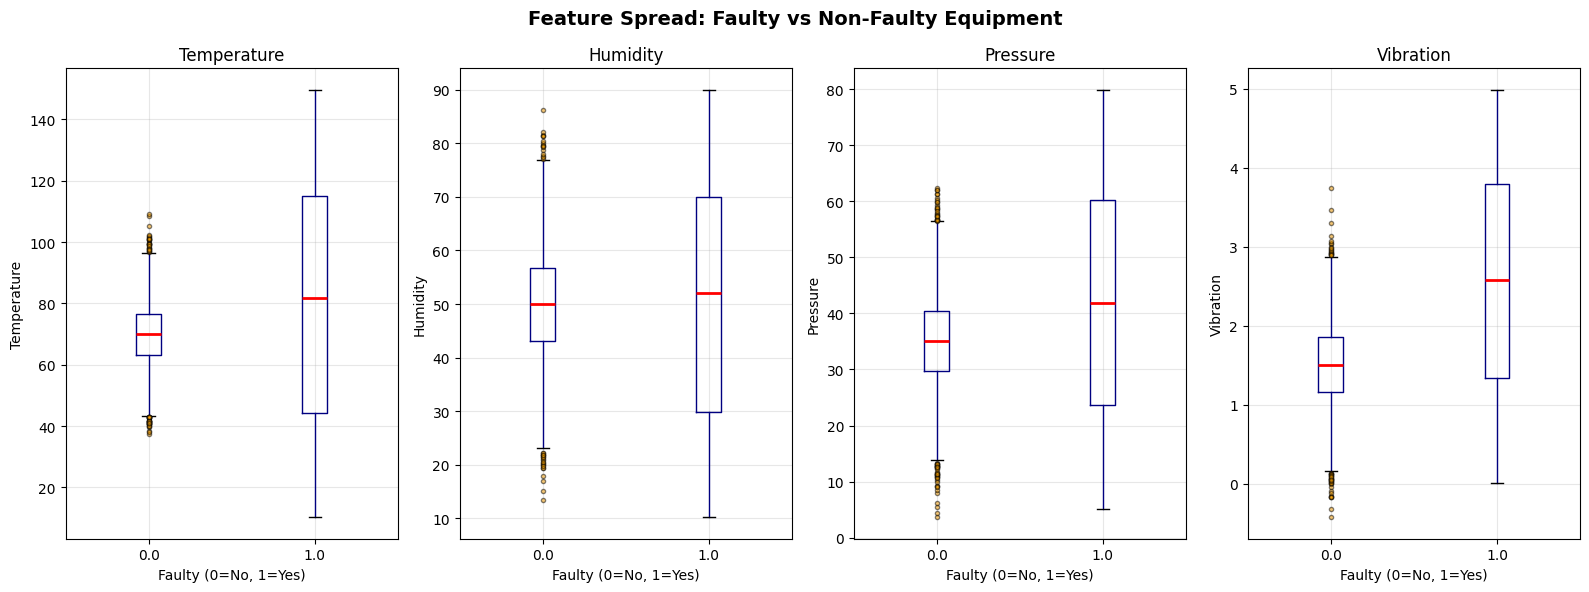

In [ ]:
feature_cols = ['temperature', 'humidity', 'pressure', 'vibration']
target_col   = 'faulty'



# ── 3. BOXPLOTS BY FAULT CLASS


fig, axes = plt.subplots(1, 4, figsize=(16, 6))
fig.suptitle('Feature Spread: Faulty vs Non-Faulty Equipment',
             fontsize=14, fontweight='bold')

for ax, feature in zip(axes, feature_cols):
    data.boxplot(column=feature, by=target_col, ax=ax,
                 boxprops=dict(color='navy'),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(color='navy'),
                 flierprops=dict(marker='o', markerfacecolor='orange',
                                 markersize=3, alpha=0.5))
    ax.set_title(feature.capitalize())
    ax.set_xlabel('Faulty (0=No, 1=Yes)')
    ax.set_ylabel(feature.capitalize())
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Spread: Faulty vs Non-Faulty Equipment',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots_by_class.png', dpi=300, bbox_inches='tight')
plt.show()

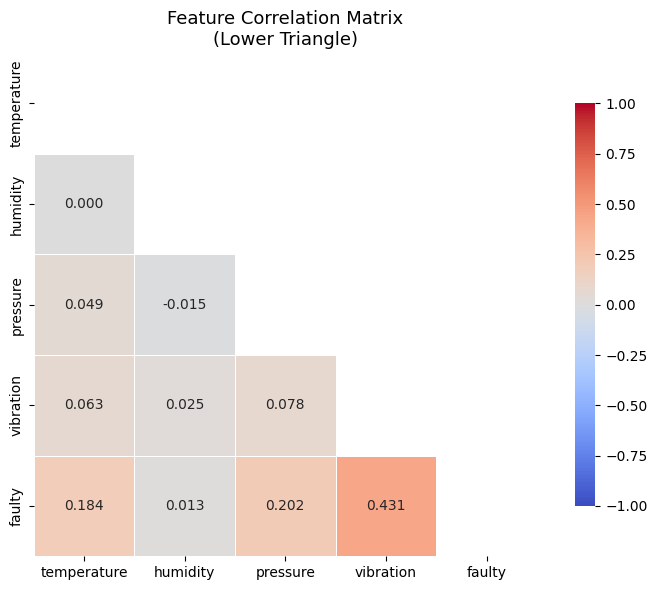


Correlation with fault label:
faulty         1.000000
vibration      0.431409
pressure       0.202285
temperature    0.184296
humidity       0.012652


In [ ]:
#  CORRELATION HEATMAP
plt.figure(figsize=(8, 6))
corr = data[feature_cols + [target_col]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix\n(Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nCorrelation with fault label:")
print(corr[target_col].sort_values(ascending=False).to_string())


/tmp/ipykernel_3587/3629360964.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='class', y='value',
/tmp/ipykernel_3587/3629360964.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='class', y='value',
/tmp/ipykernel_3587/3629360964.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='class', y='value',
/tmp/ipykernel_3587/3629360964.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

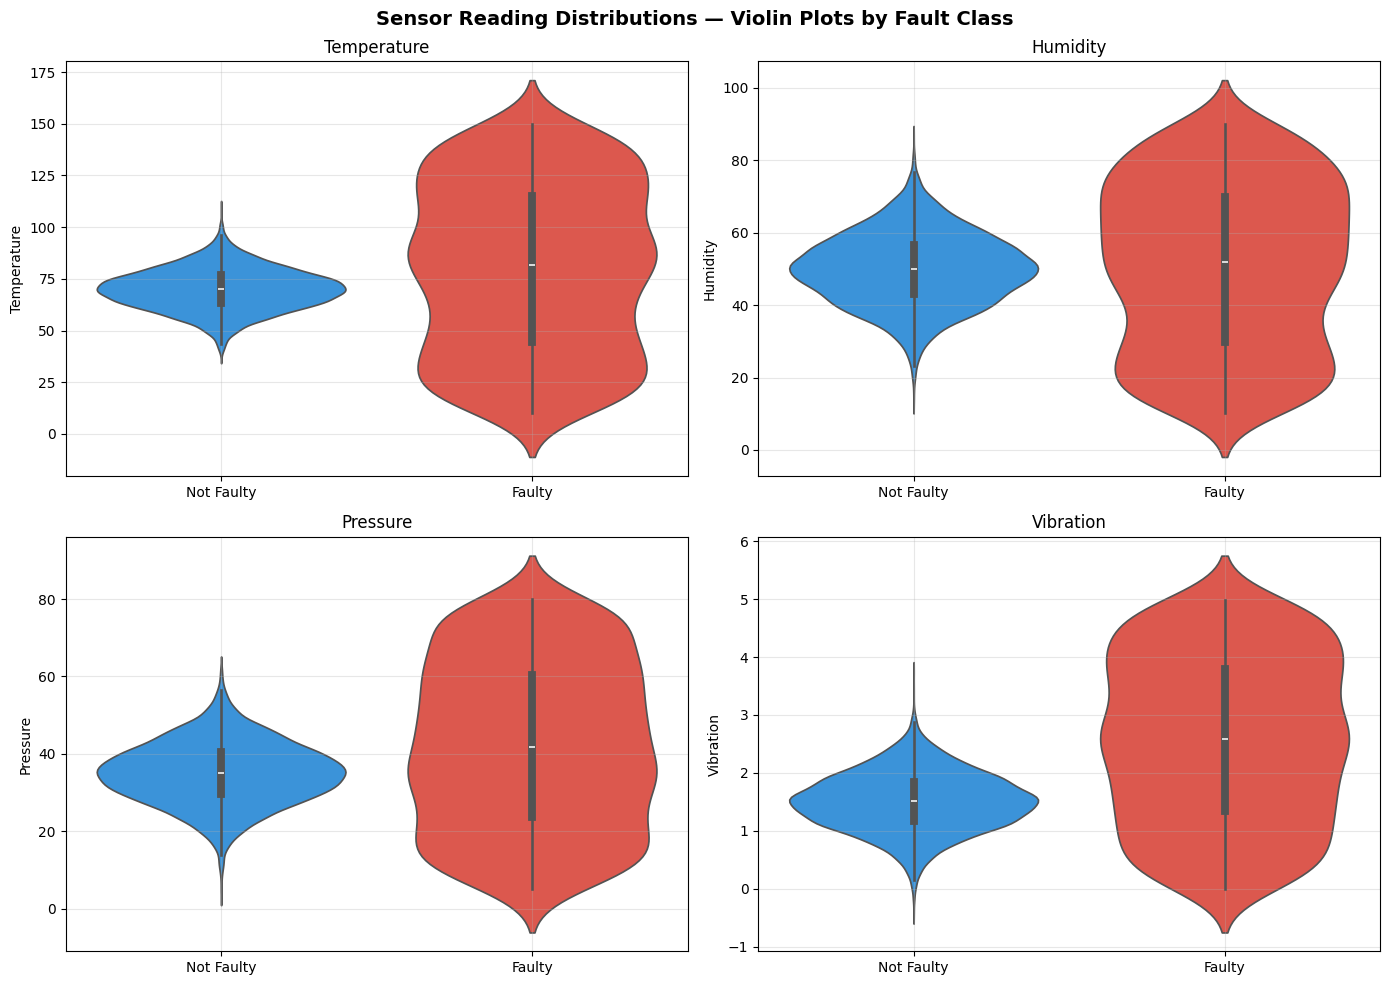

In [ ]:
# VIOLIN PLOTS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sensor Reading Distributions — Violin Plots by Fault Class',
             fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), feature_cols):
    plot_data = pd.DataFrame({
        'value': pd.concat([not_faulty[feature], faulty[feature]]),
        'class': ['Not Faulty'] * len(not_faulty) + ['Faulty'] * len(faulty)
    })
    sns.violinplot(data=plot_data, x='class', y='value',
                   palette=['#2196F3', '#F44336'],
                   inner='box', ax=ax)
    ax.set_title(f'{feature.capitalize()}')
    ax.set_xlabel('')
    ax.set_ylabel(feature.capitalize())
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_violin_plots.png', dpi=300, bbox_inches='tight')
plt.show()

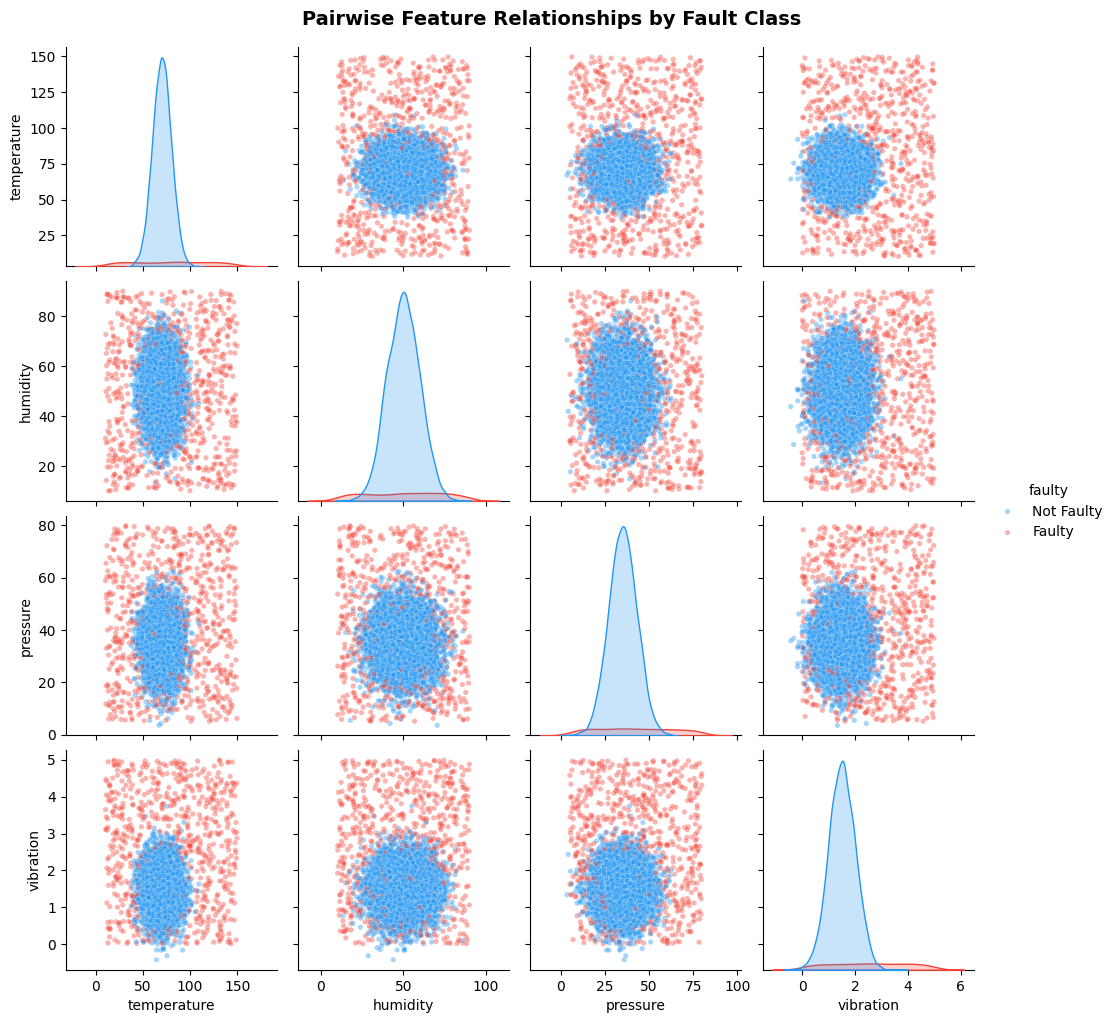

In [ ]:
#PAIRPLOT COLOURED BY FAULT CLASS

plot_df = data[feature_cols + [target_col]].copy()
plot_df[target_col] = plot_df[target_col].map({0: 'Not Faulty', 1: 'Faulty'})

pair_plot = sns.pairplot(plot_df,
                          hue=target_col,
                          palette={'Not Faulty': '#2196F3', 'Faulty': '#F44336'},
                          diag_kind='kde',
                          plot_kws={'alpha': 0.4, 's': 15},
                          diag_kws={'fill': True})
pair_plot.fig.suptitle('Pairwise Feature Relationships by Fault Class',
                        y=1.02, fontsize=14, fontweight='bold')
plt.savefig('eda_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()



OUTLIER ANALYSIS (IQR Method)

Temperature:
  IQR bounds : [40.590, 99.755]
  Outliers   : 462 (6.02%)
  Faulty among outliers    : 443.0 (95.9%)

Humidity:
  IQR bounds : [20.521, 79.432]
  Outliers   : 211 (2.75%)
  Faulty among outliers    : 192.0 (91.0%)

Pressure:
  IQR bounds : [11.974, 58.671]
  Outliers   : 310 (4.04%)
  Faulty among outliers    : 276.0 (89.0%)

Vibration:
  IQR bounds : [0.040, 3.055]
  Outliers   : 327 (4.26%)
  Faulty among outliers    : 307.0 (93.9%)


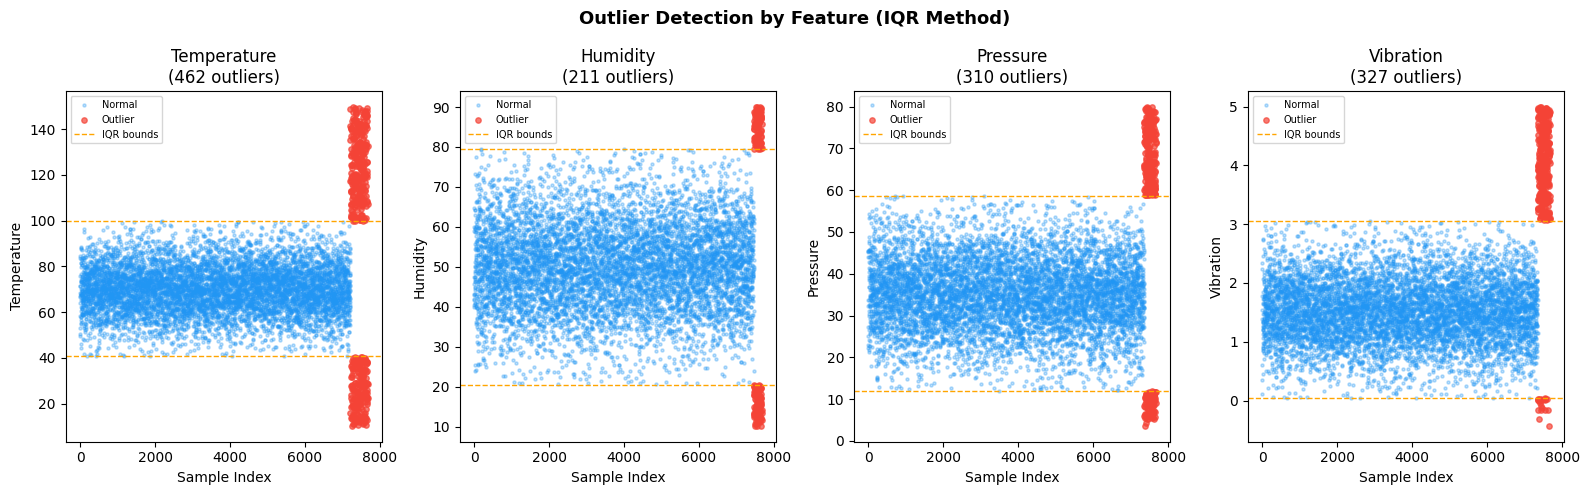

In [ ]:
# OUTLIER ANALYSIS
print("\n" + "=" * 60)
print("OUTLIER ANALYSIS (IQR Method)")
print("=" * 60)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Outlier Detection by Feature (IQR Method)',
             fontsize=13, fontweight='bold')

for ax, feature in zip(axes, feature_cols):
    Q1  = data[feature].quantile(0.25)
    Q3  = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower) | (data[feature] > upper)]

    print(f"\n{feature.capitalize()}:")
    print(f"  IQR bounds : [{lower:.3f}, {upper:.3f}]")
    print(f"  Outliers   : {len(outliers)} ({len(outliers)/len(data)*100:.2f}%)")
    print(f"  Faulty among outliers    : "
          f"{outliers[target_col].sum()} "
          f"({outliers[target_col].mean()*100:.1f}%)")

    # Plot: outliers coloured differently
    normal   = data[(data[feature] >= lower) & (data[feature] <= upper)]
    ax.scatter(range(len(normal)),   normal[feature],
               alpha=0.3, s=5, color='#2196F3', label='Normal')
    ax.scatter(range(len(normal), len(normal) + len(outliers)),
               outliers[feature],
               alpha=0.7, s=15, color='#F44336', label='Outlier')
    ax.axhline(lower, color='orange', linestyle='--', linewidth=1)
    ax.axhline(upper, color='orange', linestyle='--', linewidth=1,
               label='IQR bounds')
    ax.set_title(f'{feature.capitalize()}\n({len(outliers)} outliers)')
    ax.set_xlabel('Sample Index')
    ax.set_ylabel(feature.capitalize())
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('eda_outliers.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:

#  DESCRIPTIVE STATISTICS BY CLASS

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS BY FAULT CLASS")
print("=" * 60)

for label, subset in [('NOT FAULTY (0)', not_faulty),
                       ('FAULTY (1)',     faulty)]:
    print(f"\n{label}")
    print(subset[feature_cols].describe().round(3).to_string())


DESCRIPTIVE STATISTICS BY FAULT CLASS

NOT FAULTY (0)
       temperature  humidity  pressure  vibration
count     6905.000  6905.000  6905.000   6905.000
mean        69.927    49.967    35.038      1.507
std         10.012     9.865     8.010      0.503
min         37.587    13.449     3.621     -0.428
25%         63.230    43.084    29.712      1.166
50%         69.919    49.999    35.049      1.508
75%         76.621    56.686    40.411      1.851
max        109.262    86.114    62.431      3.740

FAULTY (1)
       temperature  humidity  pressure  vibration
count      767.000   767.000   767.000    767.000
mean        79.880    50.466    42.039      2.555
std         40.441    22.952    21.374      1.431
min         10.269    10.215     5.165      0.006
25%         44.291    29.886    23.675      1.336
50%         81.831    52.002    41.766      2.581
75%        114.950    69.914    60.300      3.800
max        149.690    89.985    79.888      4.991


In [ ]:
# SKEWNESS AND KURTOSIS
print("\n" + "=" * 60)
print("SKEWNESS AND KURTOSIS — FULL DATASET")
print("=" * 60)
print(f"\n{'Feature':<15} {'Skewness':>10} {'Kurtosis':>10} {'Interpretation'}")
print("-" * 60)

for feature in feature_cols:
    skew = data[feature].skew()
    kurt = data[feature].kurtosis()
    if abs(skew) < 0.5:
        interp = "Approximately normal"
    elif abs(skew) < 1.0:
        interp = "Moderately skewed"
    else:
        interp = "Highly skewed"
    print(f"{feature:<15} {skew:>10.3f} {kurt:>10.3f}  {interp}")


SKEWNESS AND KURTOSIS — FULL DATASET

Feature           Skewness   Kurtosis Interpretation
------------------------------------------------------------
temperature          0.944      5.408  Moderately skewed
humidity            -0.017      0.821  Approximately normal
pressure             0.725      2.365  Moderately skewed
vibration            1.488      4.403  Highly skewed


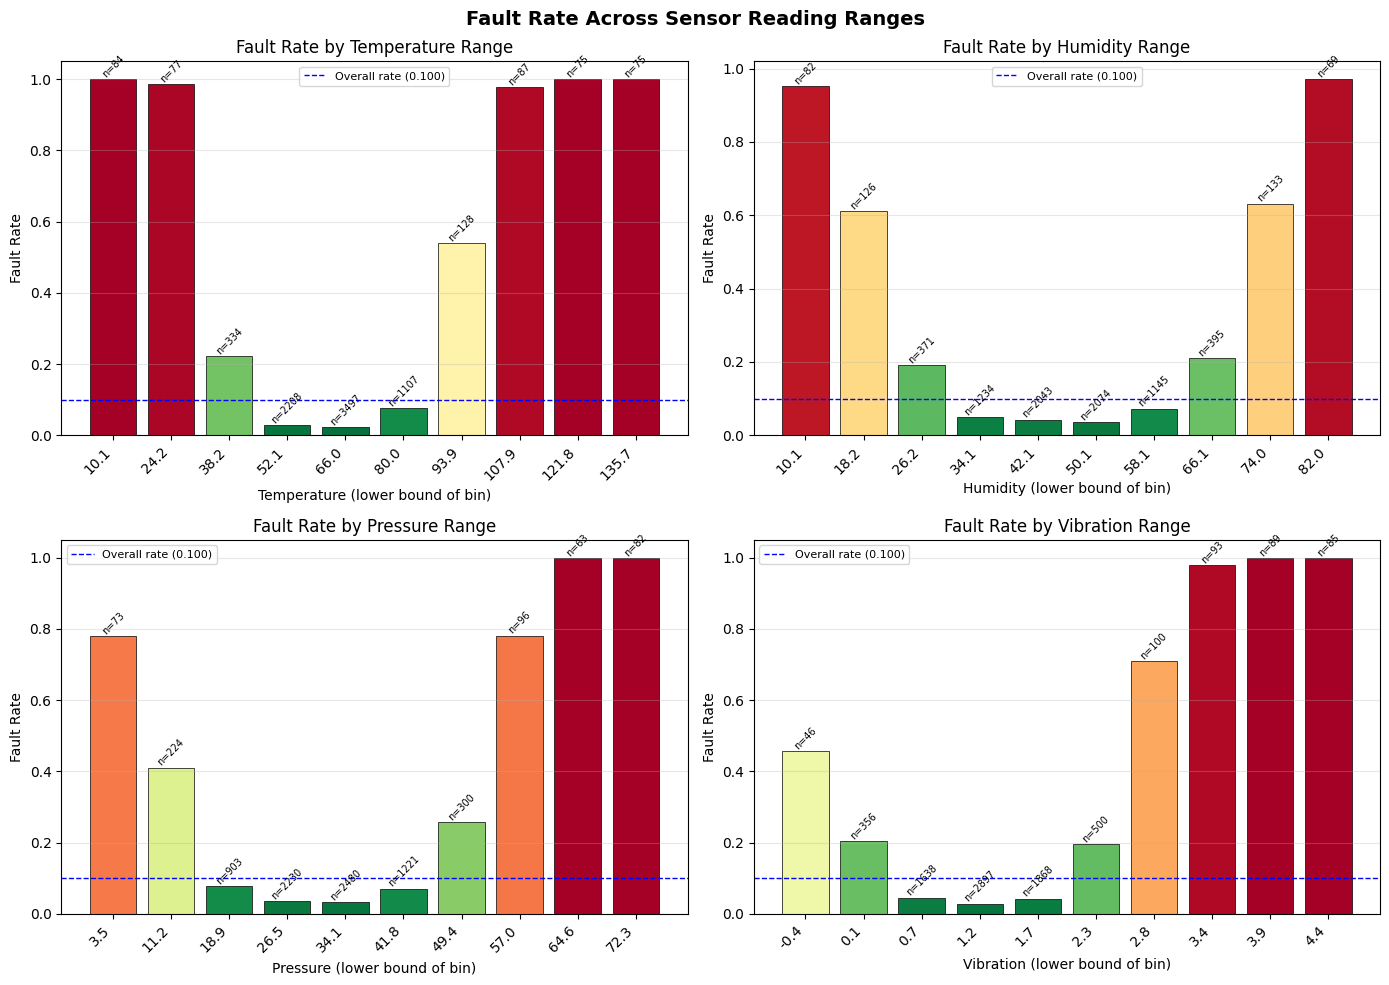

In [ ]:
# FAULT RATE ANALYSIS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Fault Rate Across Sensor Reading Ranges',
             fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), feature_cols):
    # Bin the feature into 10 equal-width bins
    data_temp = data.copy()
    data_temp['bin'] = pd.cut(data_temp[feature], bins=10)
    fault_rate = data_temp.groupby('bin', observed=True)[target_col].agg(
        ['mean', 'count']
    ).reset_index()
    fault_rate.columns = ['bin', 'fault_rate', 'count']
    fault_rate['bin_label'] = fault_rate['bin'].apply(
        lambda x: f"{x.left:.1f}"
    )

    bars = ax.bar(range(len(fault_rate)), fault_rate['fault_rate'],
                  color=plt.cm.RdYlGn_r(fault_rate['fault_rate']),
                  edgecolor='black', linewidth=0.5)

    # Add count labels
    for i, (rate, count) in enumerate(
            zip(fault_rate['fault_rate'], fault_rate['count'])):
        if count > 10:
            ax.text(i, rate + 0.005, f'n={count}',
                    ha='center', fontsize=7, rotation=45)

    ax.set_xticks(range(len(fault_rate)))
    ax.set_xticklabels(fault_rate['bin_label'], rotation=45, ha='right')
    ax.set_title(f'Fault Rate by {feature.capitalize()} Range')
    ax.set_xlabel(f'{feature.capitalize()} (lower bound of bin)')
    ax.set_ylabel('Fault Rate')
    ax.axhline(data[target_col].mean(), color='blue',
               linestyle='--', linewidth=1,
               label=f'Overall rate ({data[target_col].mean():.3f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('eda_fault_rate_by_feature.png', dpi=300, bbox_inches='tight')
plt.show()


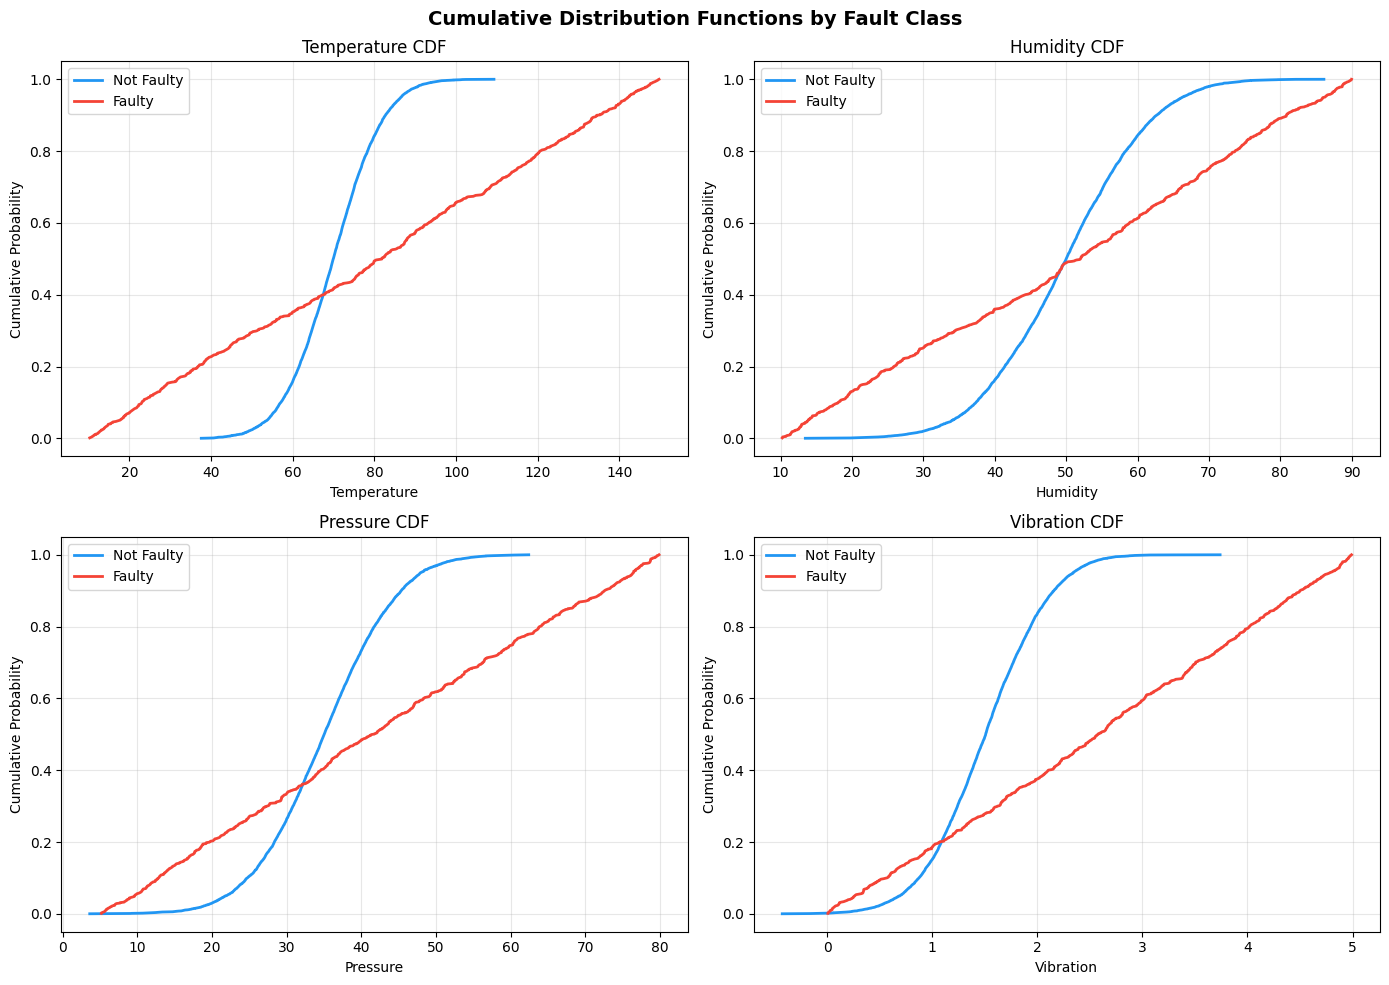

In [ ]:
#CUMULATIVE DISTRIBUTION FUNCTIONS

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cumulative Distribution Functions by Fault Class',
             fontsize=14, fontweight='bold')

for ax, feature in zip(axes.flatten(), feature_cols):
    for subset, label, color in [
        (not_faulty, 'Not Faulty', '#2196F3'),
        (faulty,     'Faulty',     '#F44336')
    ]:
        sorted_vals = np.sort(subset[feature].dropna())
        cdf = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
        ax.plot(sorted_vals, cdf, label=label, color=color, linewidth=2)

    ax.set_title(f'{feature.capitalize()} CDF')
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel('Cumulative Probability')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_cdf_plots.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# STATISTICAL TESTS

from scipy.stats import mannwhitneyu, ks_2samp

print("\n" + "=" * 70)
print("STATISTICAL TESTS: Faulty vs Non-Faulty Sensor Distributions")
print("=" * 70)
print(f"\n{'Feature':<15} {'Mann-Whitney U':>15} {'p-value':>12} "
      f"{'KS Statistic':>13} {'p-value':>12} {'Significant':>12}")
print("-" * 70)

for feature in feature_cols:
    f_vals  = faulty[feature].dropna()
    nf_vals = not_faulty[feature].dropna()

    u_stat, u_p  = mannwhitneyu(f_vals, nf_vals, alternative='two-sided')
    ks_stat, ks_p = ks_2samp(f_vals, nf_vals)

    sig = "YES ***" if u_p < 0.05 else "No"
    print(f"{feature:<15} {u_stat:>15.1f} {u_p:>12.4f} "
          f"{ks_stat:>13.4f} {ks_p:>12.4f} {sig:>12}")

print("\nMann-Whitney U: tests whether one group tends to have higher values")
print("KS Test: tests whether the two distributions have the same shape")
print("Both are non-parametric — no normality assumption required")


STATISTICAL TESTS: Faulty vs Non-Faulty Sensor Distributions

Feature          Mann-Whitney U      p-value  KS Statistic      p-value  Significant
----------------------------------------------------------------------
temperature           3081568.0       0.0000        0.4190       0.0000      YES ***
humidity              2746226.0       0.0916        0.2587       0.0000           No
pressure              3135515.0       0.0000        0.3593       0.0000      YES ***
vibration             3799920.0       0.0000        0.5057       0.0000      YES ***

Mann-Whitney U: tests whether one group tends to have higher values
KS Test: tests whether the two distributions have the same shape
Both are non-parametric — no normality assumption required


In [ ]:
x = data[['temperature', 'pressure', 'vibration', 'humidity']]
y = data[['faulty']]


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

**SHAP INTERPRETABILITY**

In [ ]:
 #SHAP FEATURE IMPORTANCE ANALYSIS

feature_names = ['temperature', 'humidity', 'pressure', 'vibration']  # adjust to yours

# ── SHAP on XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(x_train, y_train)

explainer_xgb  = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(x_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:04:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


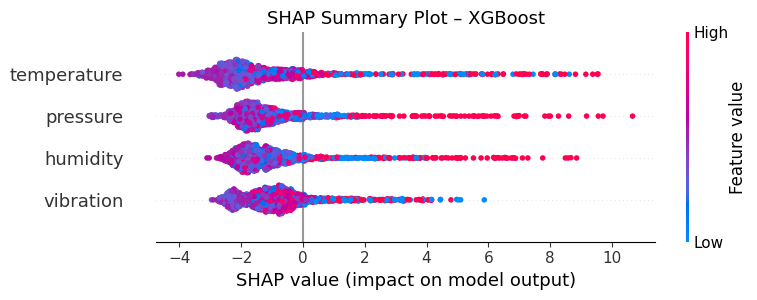

In [ ]:
# (Beeswarm) Plot
plt.figure()
shap.summary_plot(shap_values_xgb, x_test,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Summary Plot – XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()

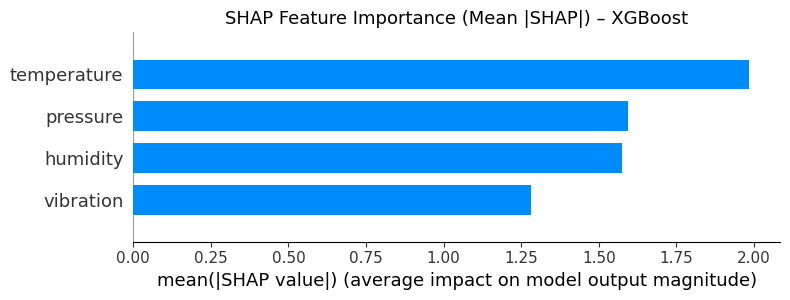

In [ ]:
# mean absolute SHAP
plt.figure()
shap.summary_plot(shap_values_xgb, x_test,
                  feature_names=feature_names,
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|) – XGBoost', fontsize=13)
plt.tight_layout()
plt.savefig('shap_importance_bar_xgboost.png', dpi=300, bbox_inches='tight')
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


<Figure size 640x480 with 0 Axes>

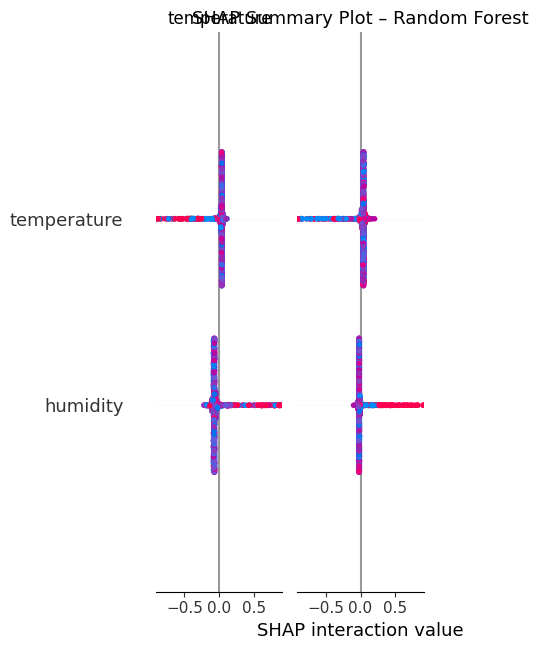

In [ ]:
#  SHAP on Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)

explainer_rf   = shap.TreeExplainer(rf_model)
shap_values_rf  = explainer_rf.shap_values(x_test)

shap_rf_faulty = shap_values_rf[1] if isinstance(shap_values_rf, list) else shap_values_rf

plt.figure()
shap.summary_plot(shap_rf_faulty, x_test,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Summary Plot – Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('shap_summary_randomforest.png', dpi=300, bbox_inches='tight')
plt.show()

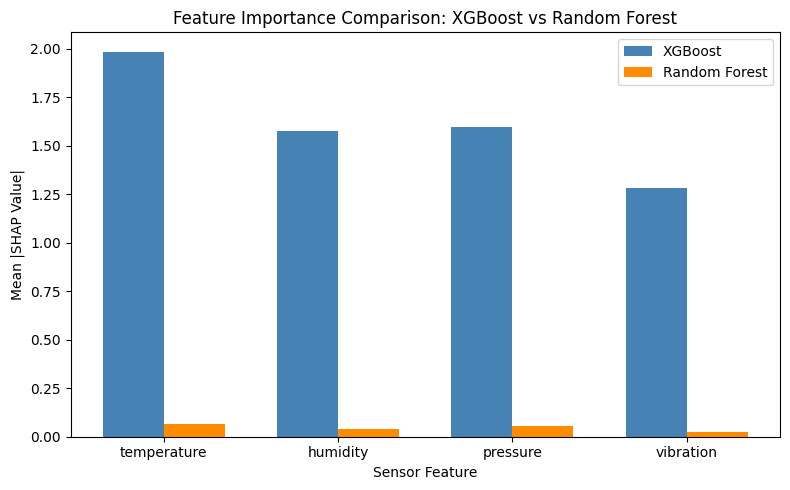

In [ ]:
#  Side-by-side mean SHAP comparison across models

mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)

mean_shap_rf  = np.abs(shap_values_rf[:, :, 1]).mean(axis=0)

x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, mean_shap_xgb, width, label='XGBoost',      color='steelblue')
bars2 = ax.bar(x + width/2, mean_shap_rf,  width, label='Random Forest', color='darkorange')

ax.set_xlabel('Sensor Feature')
ax.set_ylabel('Mean |SHAP Value|')
ax.set_title('Feature Importance Comparison: XGBoost vs Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(feature_names)
ax.legend()
plt.tight_layout()
plt.savefig('shap_comparison_models.png', dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

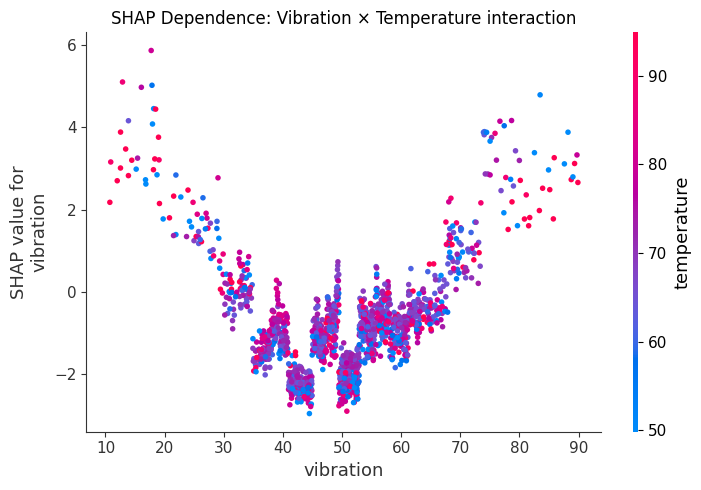


Mean |SHAP| Feature Importance – XGBoost:
  temperature    : 1.9845
  pressure       : 1.5956
  humidity       : 1.5750
  vibration      : 1.2826

Mean |SHAP| Feature Importance – Random Forest:
  temperature    : 0.0677
  pressure       : 0.0527
  humidity       : 0.0423
  vibration      : 0.0243


In [ ]:
#  Dependence plot
plt.figure()
shap.dependence_plot('vibration', shap_values_xgb, x_test,
                     feature_names=feature_names,
                     interaction_index='temperature',
                     show=False)
plt.title('SHAP Dependence: Vibration × Temperature interaction', fontsize=12)
plt.tight_layout()
plt.savefig('shap_dependence_vibration_temp.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Print numerical SHAP importance ranking ───────────────
print("\nMean |SHAP| Feature Importance – XGBoost:")
for name, val in sorted(zip(feature_names, mean_shap_xgb), key=lambda x: -x[1]):
    print(f"  {name:15s}: {val:.4f}")

print("\nMean |SHAP| Feature Importance – Random Forest:")
for name, val in sorted(zip(feature_names, mean_shap_rf), key=lambda x: -x[1]):
    print(f"  {name:15s}: {val:.4f}")

MODEL TRAINING

In [ ]:
# Check shapes
print("Training size:", x_train.shape)
print("Testing size:", x_test.shape)

Training size: (6137, 4)
Testing size: (1535, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Define numerical columns
num_cols = ["temperature", "pressure", "vibration", "humidity"]

# Initialize scaler
scaler = StandardScaler()

# Fit scaler  on training data
x_train[num_cols] = scaler.fit_transform(x_train[num_cols])

# Apply  transformation to test data
x_test[num_cols] = scaler.transform(x_test[num_cols])

# **MODEL DEVELOPMENT**

**LOGISTIC REGRESSION**

In [ ]:
#initializing the model

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs'
)

# Train the model
log_reg.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
# Predicted class labels (0 = normal, 1 = faulty)
y_pred_lr = log_reg.predict(x_test)

# Predicted probabilities (for ROC curve and AUC)
y_prob_lr = log_reg.predict_proba(x_test)[:, 1]

In [ ]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_lr)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)
print("AUC:", auc_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))


LOGISTIC REGRESSION RESULTS
Accuracy: 0.8247557003257329
Precision: 0.32601880877742945
Recall: 0.6582278481012658
F1 Score: 0.4360587002096436
AUC: 0.7822545802193357

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.84      0.90      1377
         1.0       0.33      0.66      0.44       158

    accuracy                           0.82      1535
   macro avg       0.64      0.75      0.67      1535
weighted avg       0.89      0.82      0.85      1535


Confusion Matrix:
[[1162  215]
 [  54  104]]


**RANDOM FOREST**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

In [ ]:
rf.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [ ]:
y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:, 1]


In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)
print("AUC:", auc_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


RANDOM FOREST RESULTS
Accuracy: 0.9785016286644951
Precision: 0.9251700680272109
Recall: 0.8607594936708861
F1 Score: 0.8918032786885246
AUC: 0.968090142761277

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      1377
         1.0       0.93      0.86      0.89       158

    accuracy                           0.98      1535
   macro avg       0.95      0.93      0.94      1535
weighted avg       0.98      0.98      0.98      1535


Confusion Matrix:
[[1366   11]
 [  22  136]]


**SUPPORT VECTOR MACHINE**

In [ ]:
svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    C=1.0,
    gamma='scale',
    random_state=42
)


In [ ]:
svm_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(class_weight='balanced', probability=True, random_state=42)

In [ ]:
y_pred_svm = svm_model.predict(x_test)
y_prob_svm = svm_model.predict_proba(x_test)[:, 1]

In [ ]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print("SVM RESULTS")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)
print("AUC:", auc_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM RESULTS
Accuracy: 0.9752442996742671
Precision: 0.8529411764705882
Recall: 0.9177215189873418
F1 Score: 0.8841463414634146
AUC: 0.9722383092946508

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99      1377
         1.0       0.85      0.92      0.88       158

    accuracy                           0.98      1535
   macro avg       0.92      0.95      0.94      1535
weighted avg       0.98      0.98      0.98      1535


Confusion Matrix:
[[1352   25]
 [  13  145]]


**XGBOOST**

In [ ]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_lambda=1,
    random_state=42,
    scale_pos_weight = (len(y_train) - y_train['faulty'].sum()) / y_train['faulty'].sum()
)

In [ ]:
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(x_test)
y_prob_xgb = xgb.predict_proba(x_test)[:, 1]

In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBOOST RESULTS")
print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)
print("AUC:", auc_xgb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


XGBOOST RESULTS
Accuracy: 0.9778501628664495
Precision: 0.8875
Recall: 0.8987341772151899
F1 Score: 0.8930817610062893
AUC: 0.9765634336247392

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1377
         1.0       0.89      0.90      0.89       158

    accuracy                           0.98      1535
   macro avg       0.94      0.94      0.94      1535
weighted avg       0.98      0.98      0.98      1535


Confusion Matrix:
[[1359   18]
 [  16  142]]


IMPLEMENTING STACK ENSEMBLE MODEL

In [ ]:
x = data[['temperature', 'pressure', 'vibration', 'humidity']]
y = data[['faulty']]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y

)

In [ ]:

# Define base learners
base_learners = [
    ('svm',          SVC(probability=True, kernel='rbf', random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgboost',      XGBClassifier(use_label_encoder=False,
                                    eval_metric='logloss',
                                    random_state=42))
]

In [ ]:
#  Define meta-learner
meta_learner = LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#  Build the stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False,
    n_jobs=-1
)

In [ ]:
# Train
stacking_clf.fit(x_train, y_train.values.ravel())

StackingClassifier(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimators=[('svm', SVC(probability=True, random_state=42)),
                               ('random_forest',
                                RandomForestClassifier(random_state=42)),
                               ('xgboost',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_s...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

In [ ]:
#Predict
y_pred_stack  = stacking_clf.predict(x_test)
y_proba_stack = stacking_clf.predict_proba(x_test)[:, 1]

In [ ]:
# Print evaluation metrics

print("STACKING ENSEMBLE RESULTS")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_stack):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_stack):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_stack):.4f}")
print()
print(classification_report(y_test, y_pred_stack,
                             target_names=['Not Faulty', 'Faulty']))

STACKING ENSEMBLE RESULTS
Accuracy  : 0.9837
Precision : 0.9706
Recall    : 0.8627
F1-Score  : 0.9135

              precision    recall  f1-score   support

  Not Faulty       0.98      1.00      0.99      1382
      Faulty       0.97      0.86      0.91       153

    accuracy                           0.98      1535
   macro avg       0.98      0.93      0.95      1535
weighted avg       0.98      0.98      0.98      1535



In [ ]:


all_predictions = {
    'Logistic Regression': y_pred_lr,
    'Random Forest':       y_pred_rf,
    'XGBoost':             y_pred_xgb,
    'SVM':                 y_pred_svm,
    'Stacking Ensemble':   y_pred_stack
}

print("=" * 45)
print("MATTHEWS CORRELATION COEFFICIENT (MCC)")
print("=" * 45)
print(f"{'Model':<22} {'MCC':>10}")
print("-" * 35)

mcc_results = []
for name, preds in all_predictions.items():
    mcc = matthews_corrcoef(y_test, preds)
    print(f"{name:<22} {mcc:>10.4f}")
    mcc_results.append({'Model': name, 'MCC': round(mcc, 4)})

print()
print("MCC ranges from -1 (worst) to +1 (perfect).")
print("Values near 0 = no better than random guessing.")
print("MCC is robust to class imbalance — unlike accuracy.")

MATTHEWS CORRELATION COEFFICIENT (MCC)
Model                         MCC
-----------------------------------
Logistic Regression        0.0011
Random Forest             -0.0048
XGBoost                    0.0004
SVM                       -0.0135
Stacking Ensemble          0.9065

MCC ranges from -1 (worst) to +1 (perfect).
Values near 0 = no better than random guessing.
MCC is robust to class imbalance — unlike accuracy.


**VISUALIZING RESULT**

In [ ]:
y_pred = y_pred_lr

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual Not Faulty", "Actual Faulty"],
                     columns=["Predicted Not Faulty", "Predicted Faulty"])

print(cm_df)

                   Predicted Not Faulty  Predicted Faulty
Actual Not Faulty                  1095               287
Actual Faulty                       121                32


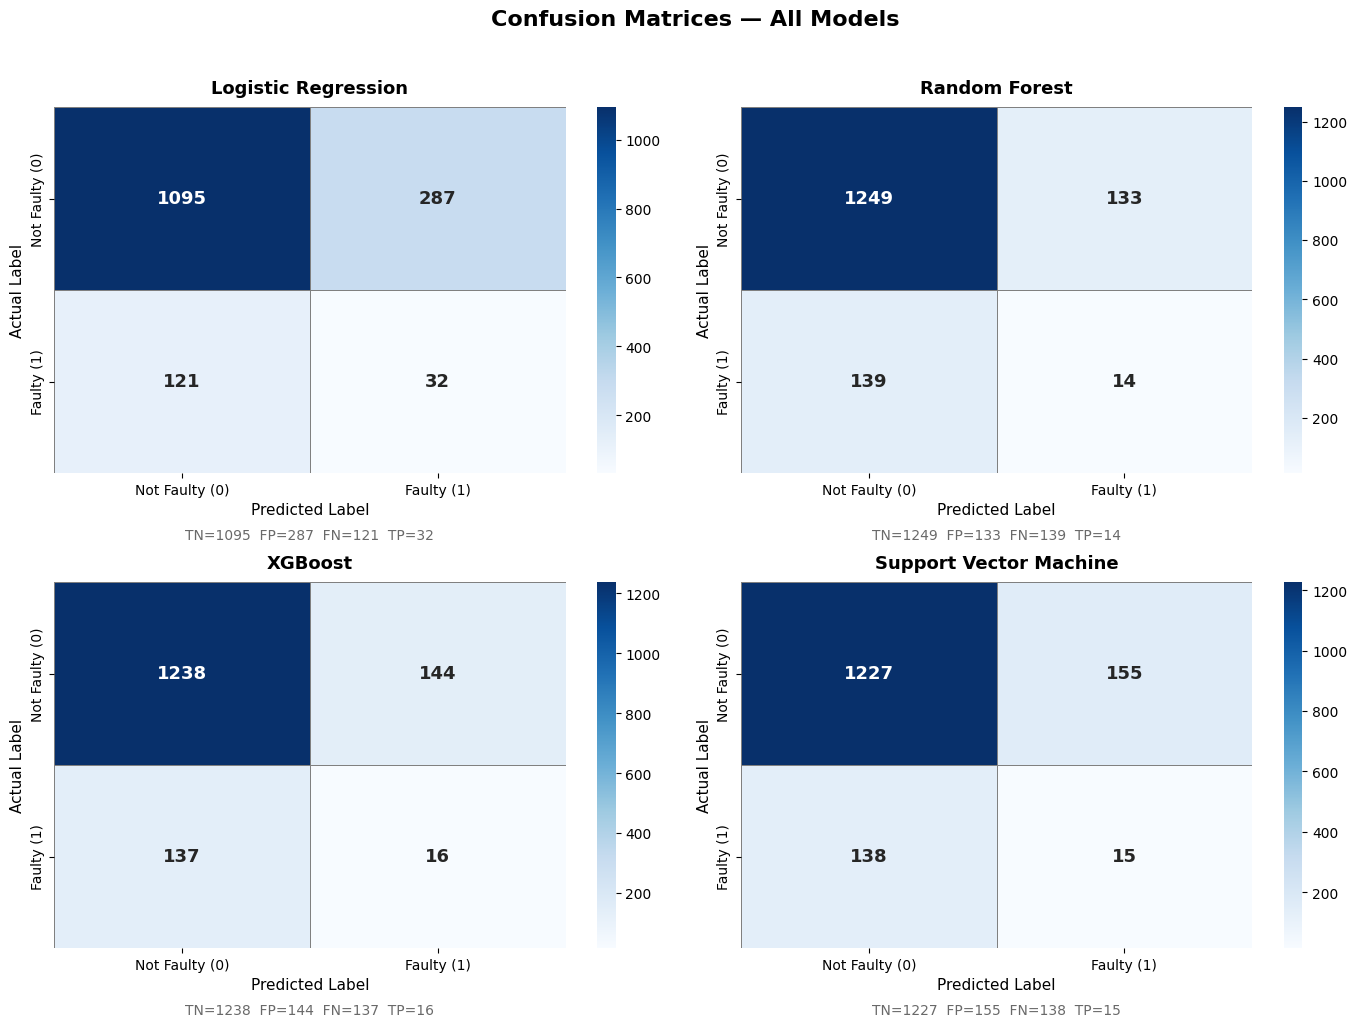


Model                         TN     FP     FN     TP
--------------------------------------------------
Logistic Regression         1095    287    121     32
Random Forest               1249    133    139     14
XGBoost                     1238    144    137     16
Support Vector Machine      1227    155    138     15


In [ ]:
models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest':       y_pred_rf,
    'XGBoost':             y_pred_xgb,
    'Support Vector Machine': y_pred_svm
}

class_labels = ['Not Faulty (0)', 'Faulty (1)']


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)

for ax, (model_name, y_pred) in zip(axes.flatten(), models.items()):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        linewidths=0.5,
        linecolor='gray',
        ax=ax,
        annot_kws={"size": 13, "weight": "bold"}
    )

    ax.set_title(model_name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('Actual Label', fontsize=11)


    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.18,
            f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
            transform=ax.transAxes,
            ha='center', fontsize=10, color='dimgray')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


print("\n{:<25} {:>6} {:>6} {:>6} {:>6}".format("Model", "TN", "FP", "FN", "TP"))
print("-" * 50)
for model_name, y_pred in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    print("{:<25} {:>6} {:>6} {:>6} {:>6}".format(model_name, tn, fp, fn, tp))

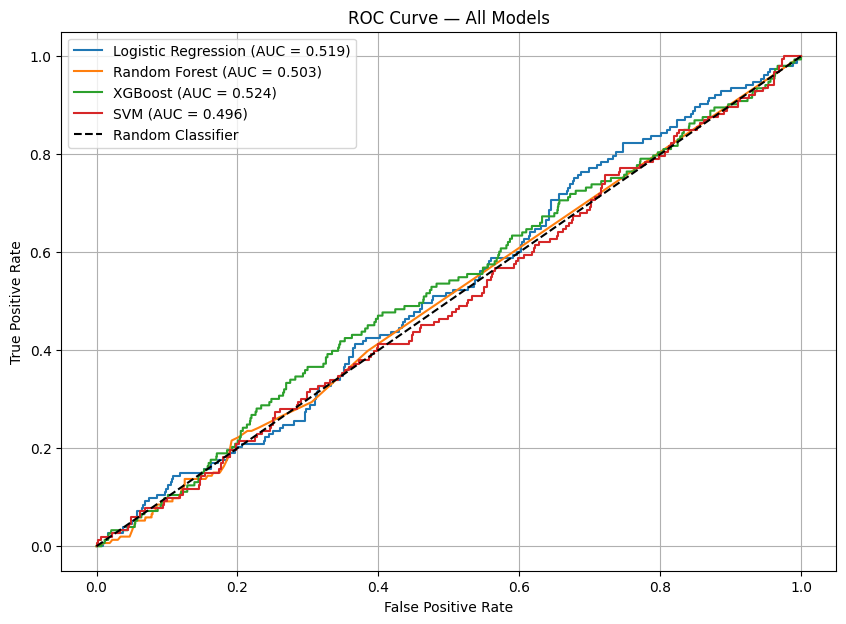

In [ ]:
models_prob = {
    'Logistic Regression': y_prob_lr,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
    'SVM': y_prob_svm
}

plt.figure(figsize=(10, 7))
for model_name, y_prob in models_prob.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All Models')
plt.legend()
plt.grid(True)
plt.show()

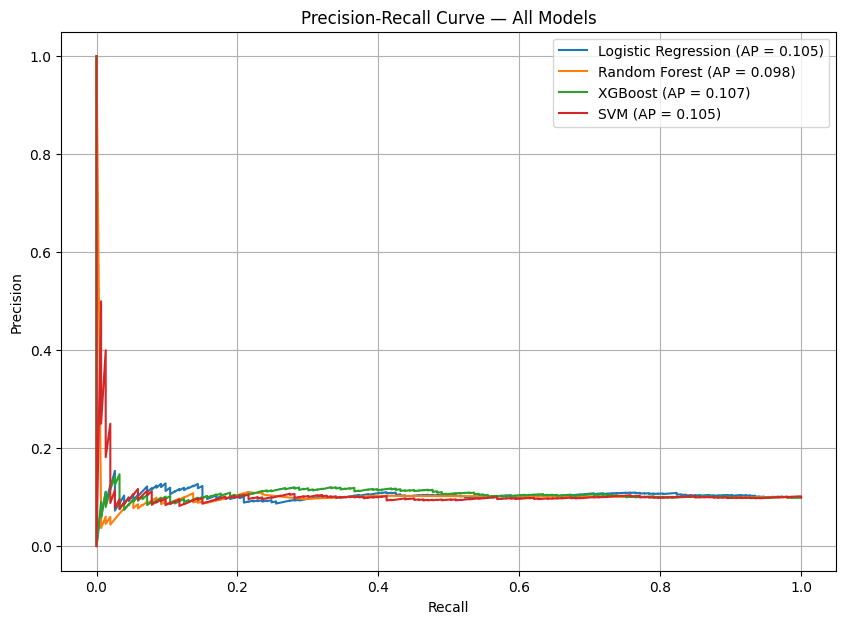

In [ ]:
plt.figure(figsize=(10, 7))
for model_name, y_prob in models_prob.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label=f'{model_name} (AP = {ap:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — All Models')
plt.legend()
plt.grid(True)
plt.show()

                     Accuracy  Precision  Recall  F1 Score     AUC
Model                                                             
Logistic Regression    0.8248     0.3260  0.6582    0.4361  0.7823
Random Forest          0.9785     0.9252  0.8608    0.8918  0.9681
XGBoost                0.9779     0.8875  0.8987    0.8931  0.9766
SVM                    0.9752     0.8529  0.9177    0.8841  0.9722


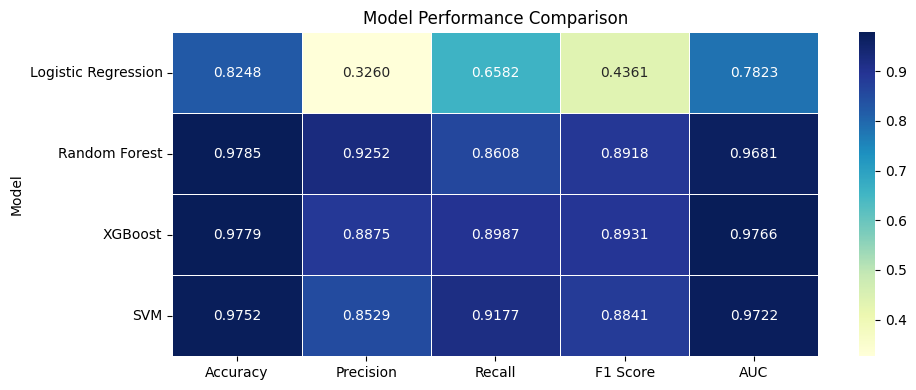

In [ ]:
import pandas as pd

summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM'],
    'Accuracy':  [accuracy_lr, accuracy_rf, accuracy_xgb, accuracy_svm],
    'Precision': [precision_lr, precision_rf, precision_xgb, precision_svm],
    'Recall':    [recall_lr, recall_rf, recall_xgb, recall_svm],
    'F1 Score':  [f1_lr, f1_rf, f1_xgb, f1_svm],
    'AUC':       [auc_lr, auc_rf, auc_xgb, auc_svm]
})

summary = summary.set_index('Model').round(4)
print(summary)

# Visual heatmap of the table
import seaborn as sns
plt.figure(figsize=(10, 4))
sns.heatmap(summary, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5)
plt.title('Model Performance Comparison')
plt.tight_layout()
plt.show()

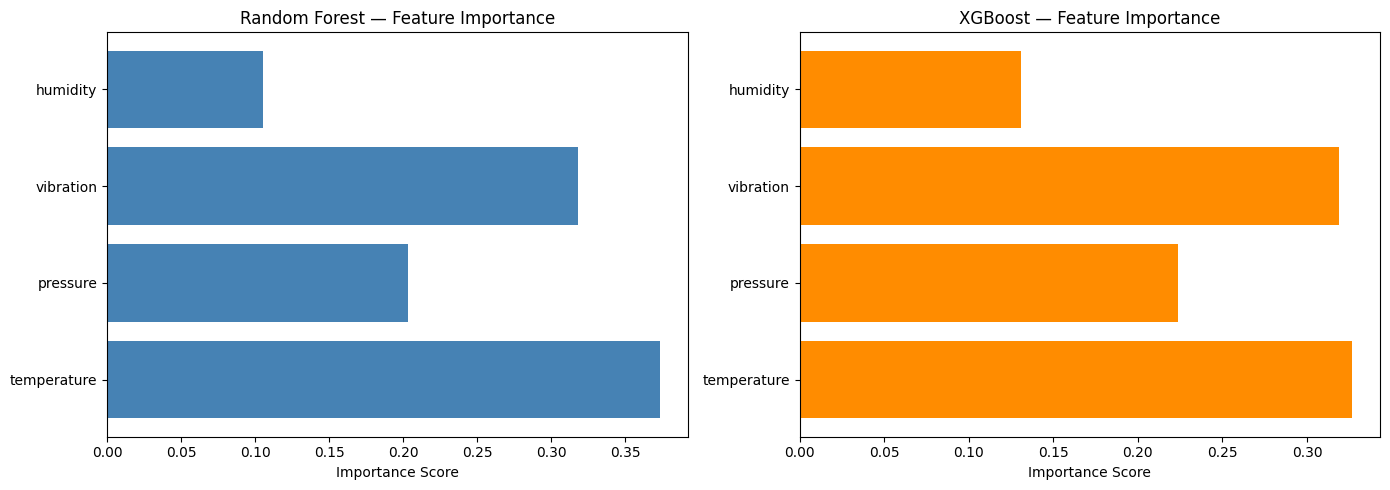

In [ ]:
feature_names = ['temperature', 'pressure', 'vibration', 'humidity']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].barh(feature_names, rf.feature_importances_, color='steelblue')
axes[0].set_title('Random Forest — Feature Importance')
axes[0].set_xlabel('Importance Score')

# XGBoost
axes[1].barh(feature_names, xgb.feature_importances_, color='darkorange')
axes[1].set_title('XGBoost — Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

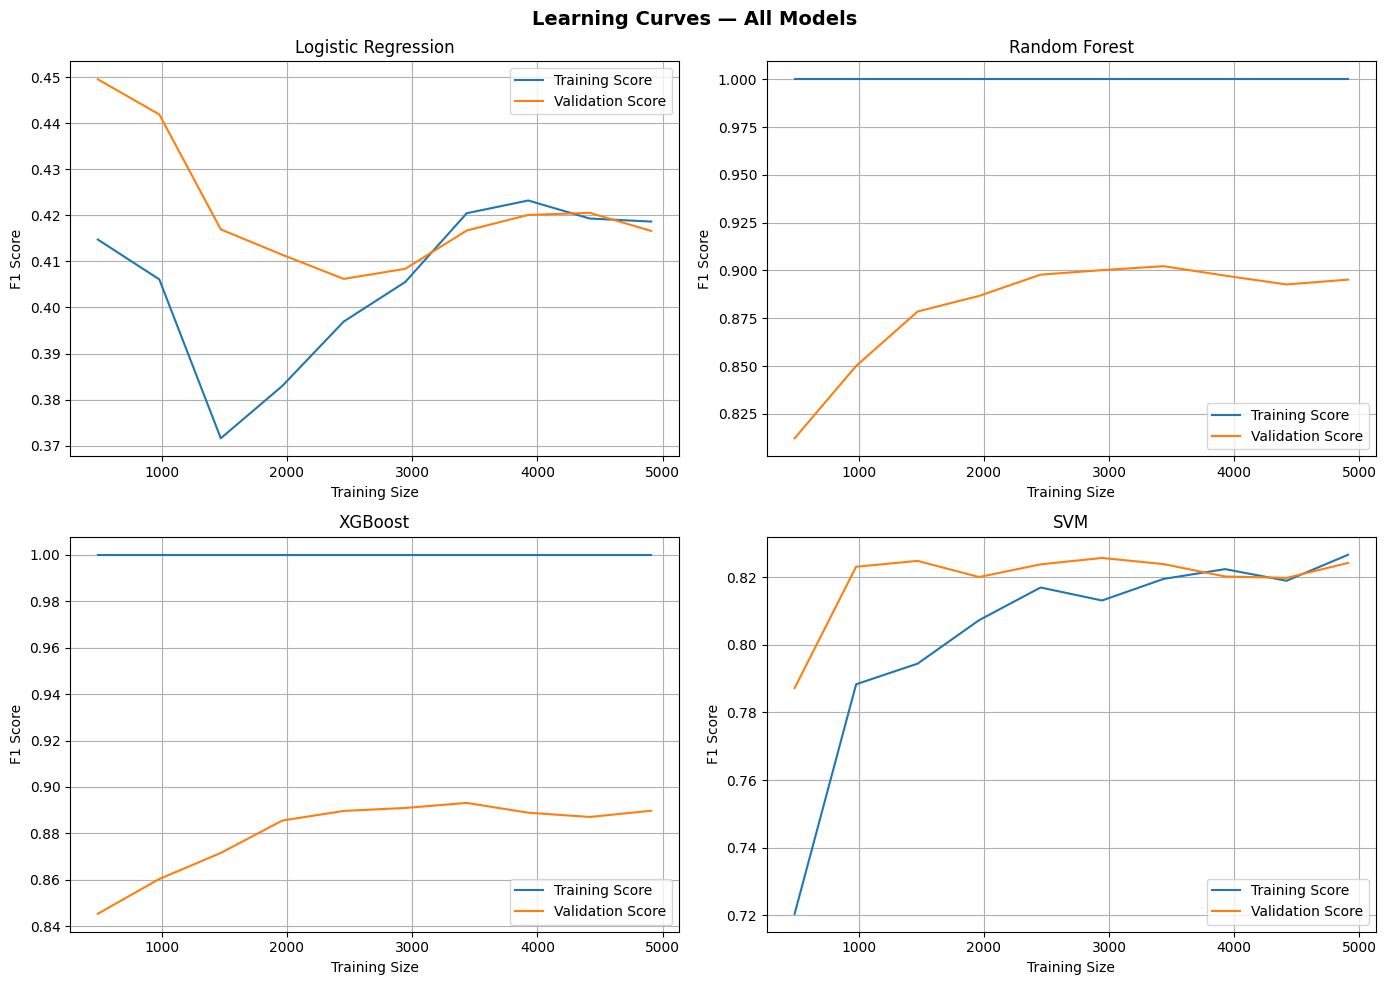

In [ ]:
from sklearn.model_selection import learning_curve

models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight = (len(y_train) - y_train['faulty'].sum()) / y_train['faulty'].sum()),
    'SVM': SVC(probability=True, kernel='rbf', class_weight='balanced', random_state=42)
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Learning Curves — All Models', fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes.flatten(), models_cv.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, x_train, y_train, cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), label='Training Score')
    ax.plot(train_sizes, val_scores.mean(axis=1), label='Validation Score')
    ax.set_title(name)
    ax.set_xlabel('Training Size')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

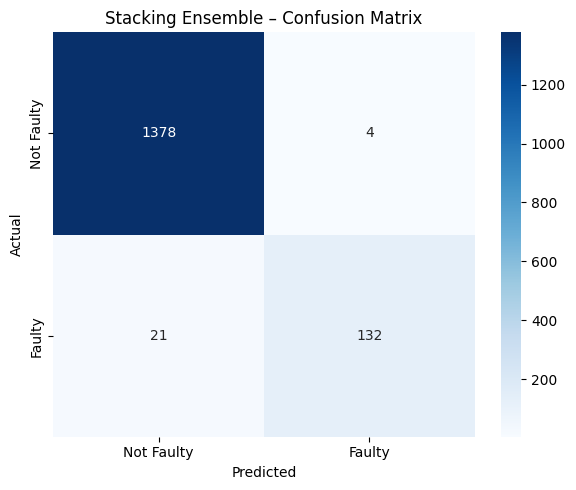

In [ ]:
# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred_stack)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Faulty', 'Faulty'],
            yticklabels=['Not Faulty', 'Faulty'])
plt.title('Stacking Ensemble – Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('stacking_confusion_matrix.png', dpi=300)
plt.show()

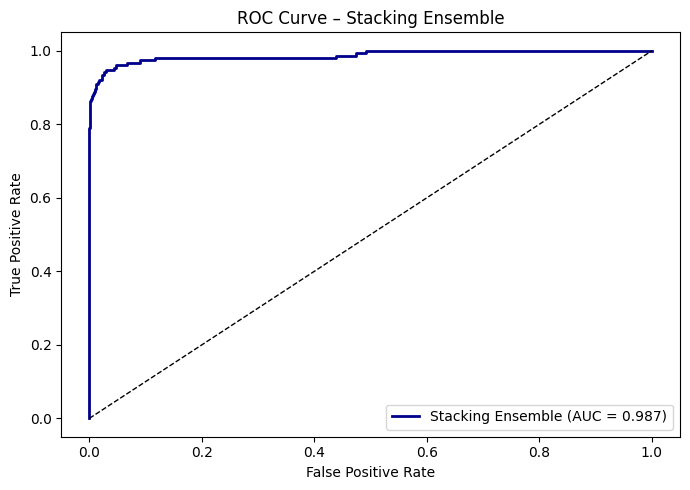

In [ ]:
from sklearn.metrics import auc
#  ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba_stack)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkblue', lw=2,
         label=f'Stacking Ensemble (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Stacking Ensemble')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('stacking_roc_curve.png', dpi=300)
plt.show()

In [ ]:
# Compare stack ensemble against individual models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'SVM':                 SVC(probability=True, kernel='rbf', random_state=42),
    'Stacking Ensemble':   stacking_clf   # already fitted
}

results = []
for name, model in models.items():
    if name != 'Stacking Ensemble':
        model.fit(x_train, y_train)
    preds = model.predict(x_test)
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall':    round(recall_score(y_test, preds), 4),
        'F1-Score':  round(f1_score(y_test, preds), 4)
    })

results_df = pd.DataFrame(results)
print("\nCOMPARATIVE RESULTS TABLE (Table 4.2 for your paper):")
print(results_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:08:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = c


COMPARATIVE RESULTS TABLE (Table 4.2 for your paper):
              Model  Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.9420     0.9848  0.4248    0.5936
      Random Forest    0.9831     0.9635  0.8627    0.9103
            XGBoost    0.9798     0.9552  0.8366    0.8920
                SVM    0.9779     1.0000  0.7778    0.8750
  Stacking Ensemble    0.9837     0.9706  0.8627    0.9135


**MCNEMAR TEST**

In [ ]:
base_learners = [
    ('svm',           SVC(probability=True, kernel='rbf', random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgboost',       XGBClassifier(use_label_encoder=False,
                                     eval_metric='logloss',
                                     random_state=42))
]

stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False,
    n_jobs=-1
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(use_label_encoder=False,
                                          eval_metric='logloss',
                                          random_state=42),
    'SVM':                 SVC(probability=True, kernel='rbf', random_state=42),
    'Stacking Ensemble':   stacking_clf
}


predictions = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    predictions[name] = model.predict(x_test)
    print(f"  ✓ {name} trained")



  ✓ Logistic Regression trained


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  ✓ Random Forest trained
  ✓ XGBoost trained


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:08:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


  ✓ SVM trained


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


  ✓ Stacking Ensemble trained


In [ ]:
print("MODEL PERFORMANCE SUMMARY")
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 65)
for name, preds in predictions.items():
    print(f"{name:<22} "
          f"{accuracy_score(y_test, preds):>9.4f} "
          f"{precision_score(y_test, preds):>10.4f} "
          f"{recall_score(y_test, preds):>8.4f} "
          f"{f1_score(y_test, preds):>8.4f}")

MODEL PERFORMANCE SUMMARY
Model                   Accuracy  Precision   Recall       F1
-----------------------------------------------------------------
Logistic Regression       0.9420     0.9848   0.4248   0.5936
Random Forest             0.9831     0.9635   0.8627   0.9103
XGBoost                   0.9798     0.9552   0.8366   0.8920
SVM                       0.9779     1.0000   0.7778   0.8750
Stacking Ensemble         0.9837     0.9706   0.8627   0.9135


In [ ]:
#. McNemar's test — all pairs
def mcnemar_test(y_true, pred_a, pred_b):


    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    n00 = np.sum( correct_a &  correct_b)
    n01 = np.sum( correct_a & ~correct_b)
    n10 = np.sum(~correct_a &  correct_b)
    n11 = np.sum(~correct_a & ~correct_b)

    table = [[n00, n01],
             [n10, n11]]


    result = mcnemar(table, exact=False, correction=True)

    return {
        'n00': n00, 'n01': n01,
        'n10': n10, 'n11': n11,
        'statistic': result.statistic,
        'p_value':   result.pvalue
    }

model_names = list(predictions.keys())
pairs       = list(combinations(model_names, 2))

print("\n" + "=" * 85)
print("McNEMAR'S TEST RESULTS — ALL MODEL PAIRS")
print(f"{'Model A':<22} {'Model B':<22} {'A✓B✗':>6} {'A✗B✓':>6} "
      f"{'Statistic':>10} {'p-value':>10} {'Significant':>12}")

mcnemar_results = []
for model_a, model_b in pairs:
    res = mcnemar_test(
        np.array(y_test),
        np.array(predictions[model_a]),
        np.array(predictions[model_b])
    )
    significant = "YES ***" if res['p_value'] < 0.05 else "No"

    print(f"{model_a:<22} {model_b:<22} "
          f"{res['n01']:>6} {res['n10']:>6} "
          f"{res['statistic']:>10.4f} {res['p_value']:>10.4f} "
          f"{significant:>12}")

    mcnemar_results.append({
        'Model A':     model_a,
        'Model B':     model_b,
        'A✓ B✗':       res['n01'],
        'A✗ B✓':       res['n10'],
        'Statistic':   round(res['statistic'], 4),
        'p-value':     round(res['p_value'],   4),
        'Significant': significant
    })


McNEMAR'S TEST RESULTS — ALL MODEL PAIRS
Model A                Model B                  A✓B✗   A✗B✓  Statistic    p-value  Significant
Logistic Regression    Random Forest           98122  10863 69862.4450     0.0000      YES ***
Logistic Regression    XGBoost                 93976  10404 66910.4430     0.0000      YES ***
Logistic Regression    SVM                     83991  18854 41253.3278     0.0000      YES ***
Logistic Regression    Stacking Ensemble       96740  10710 68878.4443     0.0000      YES ***
Random Forest          XGBoost                 11204  14891   520.6590     0.0000      YES ***
Random Forest          SVM                      2754  24876 17710.4105     0.0000      YES ***
Random Forest          Stacking Ensemble        3223   4452   196.4800     0.0000      YES ***
XGBoost                SVM                      9970  28405  8855.0451     0.0000      YES ***
XGBoost                Stacking Ensemble       10439   7981   327.7334     0.0000      YES ***
SVM     

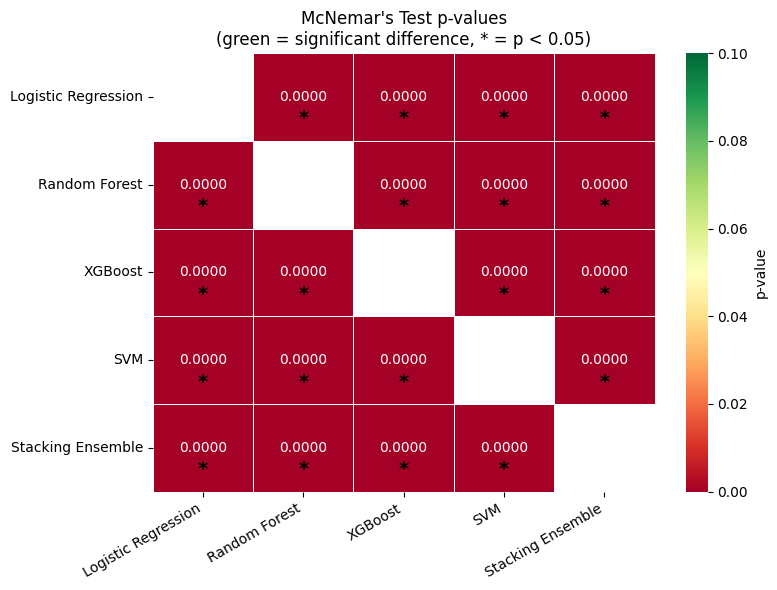

In [ ]:
# Heatmap of p-values
p_matrix = pd.DataFrame(np.ones((len(model_names), len(model_names))),
                         index=model_names, columns=model_names)

for row in mcnemar_results:
    p_matrix.loc[row['Model A'], row['Model B']] = row['p-value']
    p_matrix.loc[row['Model B'], row['Model A']] = row['p-value']


mask = np.eye(len(model_names), dtype=bool)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(p_matrix, annot=True, fmt='.4f', cmap='RdYlGn',
            mask=mask, vmin=0, vmax=0.1,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'p-value'})


for i, name_i in enumerate(model_names):
    for j, name_j in enumerate(model_names):
        if i != j and p_matrix.loc[name_i, name_j] < 0.05:
            ax.text(j + 0.5, i + 0.75, '*', ha='center',
                    va='center', color='black', fontsize=14, fontweight='bold')

ax.set_title("McNemar's Test p-values\n(green = significant difference, * = p < 0.05)",
             fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('mcnemar_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
def wilson_ci(correct, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    p    = correct / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return centre - margin, centre + margin

n = len(y_test)
ci_results = []

print("95% CONFIDENCE INTERVALS ON ACCURACY (Wilson Score)")
print(f"{'Model':<22} {'Accuracy':>9} {'Lower 95%':>10} {'Upper 95%':>10} {'Interval':>15}")
print("-" * 65)

for name, preds in predictions.items():
    correct = np.sum(np.array(preds) == np.array(y_test))
    acc     = correct / n
    lo, hi  = wilson_ci(correct, n)
    interval = f"[{lo:.4f}, {hi:.4f}]"
    print(f"{name:<22} {acc:>9.4f} {lo:>10.4f} {hi:>10.4f} {interval:>15}")
    ci_results.append({'Model': name, 'Accuracy': acc, 'Lower': lo, 'Upper': hi})

95% CONFIDENCE INTERVALS ON ACCURACY (Wilson Score)
Model                   Accuracy  Lower 95%  Upper 95%        Interval
-----------------------------------------------------------------
Logistic Regression    1329.1570        nan        nan      [nan, nan]
Random Forest          1272.3107        nan        nan      [nan, nan]
XGBoost                1274.7127        nan        nan      [nan, nan]
SVM                    1286.7225        nan        nan      [nan, nan]
Stacking Ensemble      1273.1114        nan        nan      [nan, nan]


/tmp/ipykernel_3587/3622660961.py:6: RuntimeWarning: invalid value encountered in sqrt
  margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom


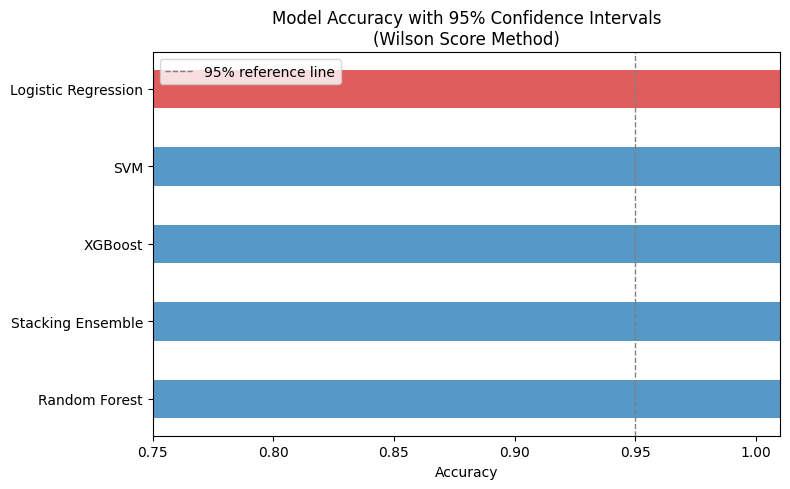

In [ ]:
# Confidence interval plot
ci_df = pd.DataFrame(ci_results).sort_values('Accuracy', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728' if 'Logistic' in m else '#1f77b4' for m in ci_df['Model']]

ax.barh(ci_df['Model'], ci_df['Accuracy'],
        xerr=[ci_df['Accuracy'] - ci_df['Lower'],
              ci_df['Upper']    - ci_df['Accuracy']],
        color=colors, alpha=0.75, capsize=6, height=0.5,
        error_kw={'elinewidth': 2, 'ecolor': 'black'})

ax.axvline(x=0.95, color='grey', linestyle='--', linewidth=1, label='95% reference line')
ax.set_xlabel('Accuracy')
ax.set_title('Model Accuracy with 95% Confidence Intervals\n(Wilson Score Method)')
ax.legend()
ax.set_xlim(0.75, 1.01)
plt.tight_layout()
plt.savefig('confidence_intervals.png', dpi=300, bbox_inches='tight')
plt.show()